# 📊 Proyecto Final Data Science: Rendimiento de Establecimientos de Salud (2005-2022)

**Autores:** Valentina Falco, Lorena Flores | **Ingenias YPF**

Este trabajo analiza cómo funcionaron los hospitales de la Provincia de Buenos Aires entre 2005 y 2022, el detalle del rendimiento de los establecimientos teniendo en cuenta la información de: cantidad de consultas odontológicas, médicas y paramédicas, interconsultas, egresos, camas disponibles, días de estadía, etc. A partir de datos oficiales, se observa el rendimiento de distintos centros de salud en cada municipio y región sanitaria. El objetivo es entender mejor cómo evolucionó el sistema hospitalario en ese período,  identificar patrones, analizar diferencias entre zonas y analizar posibles mejoras a futuro.

Dataset: https://catalogo.datos.gba.gob.ar/th/dataset/rendimientos-establecimientos-salud/archivo/8c3130cb-61ad-4014-b829-503b214ba3c0

Información detallada de las columnas: https://catalogo.datos.gba.gob.ar/dataset/219d6b32-2e34-40cb-913d-b05c47cab75f/resource/52d5fc8d-75a1-4e63-853d-92f8e938e584/download/definiciones-rendimientos-hospitalarios.pdf

### 📂 Importación de herramientas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors
import warnings
warnings.filterwarnings('ignore')

url = 'https://raw.githubusercontent.com/valentinafalco/ProyectoFinal-DS-YPF/refs/heads/main/2da%20Entrega/rendimientos-hospitalarios_2005-2022.csv'
df = pd.read_csv(url, sep=';', on_bad_lines='skip')
df.head()

,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_id,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,...,egresos,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria
0,2005,I,60007,Adolfo Alsina,NaN,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,...,1474.0,10963.0,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0
1,2005,I,60007,Adolfo Alsina,NaN,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,...,471.0,10950.0,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0
2,2005,I,60007,Adolfo Alsina,NaN,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,...,2.0,12740.0,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0
3,2005,I,60007,Adolfo Alsina,NaN,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,...,120.0,6570.0,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0
4,2005,I,60007,Adolfo Alsina,NaN,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### ⚙️ Preprocesamiento de Datos

#### 🔹 Porcentaje de filas con al menos un valor nulo

##### Explicación:

- archivo.isnull() crea un DataFrame booleano indicando dónde hay valores nulos.

- any(axis=1) verifica si alguna columna en cada fila tiene un valor nulo (devuelve True o False por fila).

- mean() calcula la proporción de filas que contienen al menos un nulo (True se interpreta como 1, False como 0).

- Multiplicamos por 100 para obtener el porcentaje.

##### Resultado:
Este valor indica el porcentaje de filas del dataset que contienen al menos un valor faltante.

In [2]:
# Porcentaje de filas con al menos un nulo
df.isnull().any(axis=1).mean() * 100

np.float64(98.99469135485856)


Significa que el 99% del dataset tiene al menos un valor faltante (nulo). Eliminar todas esas filas sería un error, porque nos quedaríamos solo con el 1% de los datos.

Revisamos cuántos valores nulos tiene cada columna y tomamos una decision

In [3]:
faltantes = df.isnull().sum()
print("Valores faltantes: \n", faltantes)

Valores faltantes: 
 anio                                0
region_sanitaria                    0
municipio_id                        0
municipio_nombre                    0
establecimiento_id              27522
establecimiento_nombre              0
dependencia                         0
consultas_odontologicas          5590
consultas_medicas                1039
consultas_paramedicas            3031
interconsultas                  10997
egresos                          9546
dias_camas_disponible            9535
promedio_camas_disponibles       9535
pacientes_dias                   9474
porcentaje_ocupacion             9540
dias_estadia                     9568
promedio_dias_estadia            9663
defunciones                      9591
giro_de_camas                    9567
tasa_mortalidad_hospitalaria     9663
dtype: int64


#### 🔹 Rellenar valores faltantes inteligentemente

Cuando encontramos datos faltantes, es importante imputarlos de manera que no distorsionen el análisis. La estrategia depende del tipo de variable y su distribución:

##### 🟦 Variables numéricas (por ejemplo: `egresos`, `dias_camas_disponible`, `defunciones`, etc.)

- **Si la variable tiene una distribución sesgada** (es decir, muchos valores extremos o asimetría en los datos), es mejor usar la **mediana** para rellenar los valores faltantes.  
  La mediana representa el valor central y no se ve afectada por valores extremos, evitando así sesgar la imputación.

- **Si la variable tiene una distribución aproximadamente simétrica**, se puede usar la **media** para imputar.  
  La media es el promedio y funciona bien cuando los datos no tienen valores atípicos fuertes.

- **En algunos casos específicos**, si el valor 0 representa la ausencia de un evento (por ejemplo, "0 egresos" podría indicar que no hubo egresos), se puede rellenar con 0.  
  Esto debe hacerse solo cuando tiene sentido desde el punto de vista del negocio o dominio de los datos.


Esta estrategia busca mantener la integridad de los datos y minimizar el impacto de los valores faltantes en el análisis.


In [4]:
columnas_numericas = [
    'consultas_odontologicas', 'consultas_medicas', 'consultas_paramedicas',
    'interconsultas', 'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
    'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia', 
    'promedio_dias_estadia', 'defunciones', 'giro_de_camas', 'tasa_mortalidad_hospitalaria'
]

df[columnas_numericas].skew().sort_values()

tasa_mortalidad_hospitalaria     7.348261
defunciones                      7.942451
promedio_camas_disponibles       9.638751
dias_camas_disponible            9.665125
consultas_medicas               10.113048
giro_de_camas                   11.319577
pacientes_dias                  11.426462
egresos                         11.861566
consultas_paramedicas           12.386282
interconsultas                  12.668978
dias_estadia                    14.628040
promedio_dias_estadia           15.044635
porcentaje_ocupacion            20.299912
consultas_odontologicas         21.461145
dtype: float64

#### ✅ Interpretación rápida

###### ✔️ **Distribución aproximadamente simétrica** (skew entre -0.5 y 0.5):

Ninguna de tus columnas está en este rango → ninguna tiene simetría ideal.

##### ⚠️ **Moderadamente sesgada** (skew entre ±0.5 y ±1):

- `tasa_mortalidad_hospitalaria` → 7.34  
- `defunciones` → 7.94  
  → _Ya están bastante más allá del límite: son muy sesgadas, en realidad_.

##### ❗ **Altamente sesgada** (skew > 1 o < -1):

| Variable                     | Skew  | ¿Sesgada?        | ¿Qué usar?  |
|------------------------------|-------|------------------|-------------|
| `tasa_mortalidad_hospitalaria` | 7.35  | Sí, fuertemente  | **mediana** |
| `defunciones`                 | 7.94  | Sí, fuertemente  | **mediana** |
| `promedio_camas_disponibles`  | 9.64  | Sí               | **mediana** |
| `dias_camas_disponible`       | 9.66  | Sí               | **mediana** |
| `consultas_medicas`           | 10.11 | Sí               | **mediana** |
| `giro_de_camas`               | 11.31 | Sí               | **mediana** |
| `pacientes_dias`              | 11.43 | Sí               | **mediana** |
| `egresos`                    | 11.86 | Sí               | **mediana** |
| `consultas_paramedicas`       | 12.39 | Sí               | **mediana** |
| `interconsultas`              | 12.67 | Sí               | **mediana** |
| `dias_estadia`                | 14.63 | Sí               | **mediana** |
| `promedio_dias_estadia`       | 15.04 | Sí               | **mediana** |
| `porcentaje_ocupacion`        | 20.30 | Sí               | **mediana** |
| `consultas_odontologicas`     | 21.46 | Sí               | **mediana** |

##### ✅ Conclusión:

> 💡 **Todas las variables tienen una distribución altamente sesgada**.  
> 👉 Por lo tanto, **conviene imputar los nulos con la _mediana_ y no con la media**, porque la media estaría distorsionada por los valores extremos.


In [5]:
# Seleccionar solo columnas numéricas
columnas_numericas = df.select_dtypes(include=['number']).columns

# Calcular el % de valores nulos SOLO en columnas numéricas
null_percent = df[columnas_numericas].isnull().mean() * 100

# Categorías de columnas según % de nulos
menos_10 = null_percent[null_percent < 10].index
entre_10_15 = null_percent[(null_percent >= 10) & (null_percent <= 15)].index
mas_15 = null_percent[null_percent > 15].index

# 1. Rellenar con la media las columnas numéricas con menos del 10% de nulos
df[menos_10] = df[menos_10].fillna(df[menos_10].mean())

# 2. Rellenar con la mediana las columnas numéricas con entre 10% y 15% de nulos
df[entre_10_15] = df[entre_10_15].fillna(df[entre_10_15].median())

# 3. Mostrar columnas numéricas con más del 15% de nulos (sin modificarlas)
print("\n❗ Columnas numéricas con más del 15% de valores nulos:")
for col in mas_15:
    print(f"- {col}: {null_percent[col]:.2f}% nulos")

# Verificación general de columnas numéricas
print("\n✅ Porcentaje de nulos después de rellenar (solo numéricas):")
print(df[columnas_numericas].isnull().mean() * 100)


❗ Columnas numéricas con más del 15% de valores nulos:
- establecimiento_id: 70.58% nulos
- interconsultas: 28.20% nulos
- egresos: 24.48% nulos
- dias_camas_disponible: 24.45% nulos
- promedio_camas_disponibles: 24.45% nulos
- pacientes_dias: 24.30% nulos
- porcentaje_ocupacion: 24.47% nulos
- dias_estadia: 24.54% nulos
- promedio_dias_estadia: 24.78% nulos
- defunciones: 24.60% nulos
- giro_de_camas: 24.54% nulos
- tasa_mortalidad_hospitalaria: 24.78% nulos

✅ Porcentaje de nulos después de rellenar (solo numéricas):
anio                             0.000000
municipio_id                     0.000000
establecimiento_id              70.581899
consultas_odontologicas          0.000000
consultas_medicas                0.000000
consultas_paramedicas            0.000000
interconsultas                  28.202498
egresos                         24.481317
dias_camas_disponible           24.453107
promedio_camas_disponibles      24.453107
pacientes_dias                  24.296669
porcentaje_o

#### Decisión para imputar valores faltantes en columnas numéricas con más del 15% de nulos

Luego de analizar el porcentaje de valores nulos y la distribución de las columnas numéricas, decidimos imputar los valores faltantes con la **mediana** en las siguientes columnas que tienen más del 15% de nulos:

- `interconsultas`
- `egresos`
- `dias_camas_disponible`
- `promedio_camas_disponibles`
- `pacientes_dias`
- `porcentaje_ocupacion`
- `dias_estadia`
- `promedio_dias_estadia`
- `defunciones`
- `giro_de_camas`
- `tasa_mortalidad_hospitalaria`

##### Justificación de esta decisión:

- **Distribución sesgada:**  
  Estas columnas presentan una distribución fuertemente sesgada, con valores extremos que distorsionan la media. Por eso, la mediana es un mejor estadístico para rellenar los nulos, ya que representa el valor central y no se ve afectada por valores atípicos.

- **Porcentaje significativo de nulos:**  
  Al tener más del 15% de datos faltantes, eliminar filas con nulos reduciría demasiado la cantidad de datos disponibles, lo cual puede perjudicar el análisis.

- **Evitar imputar con 0 o media:**  
  Imputar con 0 podría introducir un sesgo falso y no representa realmente la ausencia del dato. Imputar con la media, dado el sesgo, puede distorsionar los resultados.

- **Manejo seguro en pandas:**  
  Se utilizó una asignación directa para evitar warnings relacionados con la modificación de copias en pandas.


In [6]:
# Lista de columnas numéricas con más del 15% de nulos
columnas_mediana = [
    'interconsultas',
    'egresos',
    'dias_camas_disponible',
    'promedio_camas_disponibles',
    'pacientes_dias',
    'porcentaje_ocupacion',
    'dias_estadia',
    'promedio_dias_estadia',
    'defunciones',
    'giro_de_camas',
    'tasa_mortalidad_hospitalaria'
]

# Rellenar con la mediana sin generar warnings
for col in columnas_mediana:
    mediana = df[col].median()
    df[col] = df[col].fillna(mediana)

# Información general del dataframe para ver nulos y tipos
print(df[columnas_mediana].info())

# Mostrar las primeras filas para verificar algunos valores
print(df[columnas_mediana].head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38993 entries, 0 to 38992
Data columns (total 11 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   interconsultas                38993 non-null  float64
 1   egresos                       38993 non-null  float64
 2   dias_camas_disponible         38993 non-null  float64
 3   promedio_camas_disponibles    38993 non-null  float64
 4   pacientes_dias                38993 non-null  float64
 5   porcentaje_ocupacion          38993 non-null  float64
 6   dias_estadia                  38993 non-null  float64
 7   promedio_dias_estadia         38993 non-null  float64
 8   defunciones                   38993 non-null  float64
 9   giro_de_camas                 38993 non-null  float64
 10  tasa_mortalidad_hospitalaria  38993 non-null  float64
dtypes: float64(11)
memory usage: 3.3 MB
None
   interconsultas  egresos  dias_camas_disponible  promedio_camas_disponibles 

In [7]:
print(df.isnull().sum().sum())  # Debería dar 0 si no hay nulos

27522


##### ¿Por qué el dataset todavía tiene valores nulos?

Después de imputar las columnas numéricas con más del 15% de valores nulos utilizando la **mediana**, ejecutamos:

- print(df.isnull().sum().sum())

Este comando suma todos los valores nulos del DataFrame y no devuelve 0, lo que indica que todavía quedan datos faltantes.

##### ¿Qué columnas siguen teniendo nulos?
La principal razón es que `establecimiento_id` sigue conteniendo valores nulos. Esta columna representa un identificador categórico, por lo que no es apropiado imputarla con medianas o medias como hicimos con las columnas numéricas.
Se resolverá en los proximos pasos

#### 🔹 Preprocesamos la columna dependencia para facilitar el análisis. 
Agregamos una nueva columna llamada `dependencia_id` al DataFrame, donde cada tipo de dependencia se mapea a un valor numérico:

- 'Municipal' se mapea a 1
- 'Provincial' se mapea a 2
- 'Nacional' se mapea a 3

In [8]:
# Crear un diccionario para mapear los valores de dependencia a IDs numéricos
dependencia_mapping = {
    'Municipal': 1,
    'Provincial': 2,
    'Nacional': 3
}

# Crear la nueva columna 'dependencia_id' usando el mapeo
# Usamos .loc para evitar SettingWithCopyWarning
df.loc[:, 'dependencia_id'] = df['dependencia'].map(dependencia_mapping)

# Mostrar las primeras filas y el conteo de valores para la nueva columna para verificar
print("DataFrame con la nueva columna 'dependencia_id':")
display(df[['dependencia', 'dependencia_id']].head())

print("\nConteo de valores en la columna 'dependencia_id':")
display(df['dependencia_id'].value_counts().sort_index())

# Verificar si hay dependencias que no fueron mapeadas (tendrán valores NaN en dependencia_id)
unmapped_dependencies = df[df['dependencia_id'].isnull()]['dependencia'].unique()
if len(unmapped_dependencies) > 0:
    print(f"\n¡Advertencia! Se encontraron dependencias que no fueron mapeadas: {unmapped_dependencies}")
    print("Considera agregarlas al diccionario 'dependencia_mapping' si es necesario.")

DataFrame con la nueva columna 'dependencia_id':


,dependencia,dependencia_id
0,Municipal,1
1,Municipal,1
2,Municipal,1
3,Municipal,1
4,Municipal,1



Conteo de valores en la columna 'dependencia_id':


dependencia_id
1    37259
2     1649
3       85
Name: count, dtype: int64

### ⁉️Inconsistencia en los datos de la columna `establecimiento_id`

Se determino la necesidad de crear una nueva columna `establecimiento_id` en el DataFrame df, donde cada valor único en establecimiento_nombre tendrá asignado un ID numérico único.

In [9]:
# Eliminar la columna 'establecimiento_id' del DataFrame df
if 'establecimiento_id' in df.columns:
    df = df.drop('establecimiento_id', axis=1)
    print("La columna 'establecimiento_id' ha sido eliminada.")
else:
    print("La columna 'establecimiento_id' no se encuentra en el DataFrame.")

# Mostrar las primeras filas del DataFrame para verificar el cambio
display(df.head())

La columna 'establecimiento_id' ha sido eliminada.


,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,...,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,0.0,...,10963.0,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,0.0,...,10950.0,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0,1
2,2005,I,60007,Adolfo Alsina,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,0.0,...,12740.0,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0,1
3,2005,I,60007,Adolfo Alsina,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,0.0,...,6570.0,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0,1
4,2005,I,60007,Adolfo Alsina,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1


In [10]:
# Obtener todos los nombres únicos de los establecimientos
unique_establishment_names = df['establecimiento_nombre'].unique()

# Crear un mapeo de nombres únicos a IDs enteros únicos
# Podemos usar pandas factorize para esto, que es eficiente
name_to_id_mapping, unique_ids = pd.factorize(df['establecimiento_nombre'])# factorize devuelve un array de códigos enteros, que se pueden asignar directamente

# Asignar estos nuevos IDs únicos al DataFrame
df['establecimiento_id'] = name_to_id_mapping + 1 # Sumar 1 para que los IDs empiecen desde 1 en lugar de 0

# Mostrar las primeras filas con la nueva columna y verificar la unicidad para algunos nombres
print("DataFrame con la nueva columna 'establecimiento_id' única por nombre:")
display(df[['establecimiento_nombre', 'establecimiento_id']].head())

print("\nVerificando IDs únicos para algunos nombres de establecimientos:")
# Seleccionar algunos nombres únicos para mostrar sus IDs asignados
names_to_verify = df['establecimiento_nombre'].sample(5).tolist() if len(df) > 5 else df['establecimiento_nombre'].unique()[:5].tolist()
for name in names_to_verify:
    # Obtener todos los IDs únicos para este nombre (debería ser solo uno)
    unique_ids_for_name = df[df['establecimiento_nombre'] == name]['establecimiento_id'].unique()
    print(f"  - '{name}': ID(s) asignado(s): {unique_ids_for_name}")

# Verificar que el número de establecimiento_id únicos sea igual al número de establecimiento_nombre únicos
num_unique_names = df['establecimiento_nombre'].nunique()
num_unique_ids = df['establecimiento_id'].nunique()

print(f"\nNúmero de nombres de establecimiento únicos: {num_unique_names}")
print(f"Número de IDs de establecimiento únicos: {num_unique_ids}")

if num_unique_names == num_unique_ids:
    print("Verificación exitosa: Cada nombre de establecimiento tiene un ID único.")
else:
    print("Advertencia: El número de nombres únicos no coincide con el número de IDs únicos.")

DataFrame con la nueva columna 'establecimiento_id' única por nombre:


,establecimiento_nombre,establecimiento_id
0,Hospital Local General José de San Martín,1
1,Hospital Dr. Noe Yarcho,2
2,Hogar de Ancianos General N. Levalle,3
3,Hospital Demetrio Carmelo Loyarte,4
4,Unidad Sanitaria San Miguel Arcangel,5



Verificando IDs únicos para algunos nombres de establecimientos:
  - 'Unidad Sanitaria Madre Teresa de Calcuta': ID(s) asignado(s): [521]
  - 'Centro de Salud Nº 31': ID(s) asignado(s): [786]
  - 'C.A.P.S. Open Door': ID(s) asignado(s): [2782]
  - 'Unidad Sanitaria Barrio Fonavi II': ID(s) asignado(s): [254]
  - 'Sala de Primeros Auxilios Villa Italia': ID(s) asignado(s): [2851]

Número de nombres de establecimiento únicos: 5225
Número de IDs de establecimiento únicos: 5225
Verificación exitosa: Cada nombre de establecimiento tiene un ID único.


In [11]:
# Vemos el DataFrame con las nuevas columna establecimiento_id y dependencia_id

display(df.head())

,anio,region_sanitaria,municipio_id,municipio_nombre,establecimiento_nombre,dependencia,consultas_odontologicas,consultas_medicas,consultas_paramedicas,interconsultas,...,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,defunciones,giro_de_camas,tasa_mortalidad_hospitalaria,dependencia_id,establecimiento_id
0,2005,I,60007,Adolfo Alsina,Hospital Local General José de San Martín,Municipal,6424.0,94401.0,18888.0,0.0,...,30.0,4798.0,44.0,4529.0,3.0,42.0,49.0,3.0,1,1
1,2005,I,60007,Adolfo Alsina,Hospital Dr. Noe Yarcho,Municipal,4493.0,18370.0,4459.0,0.0,...,30.0,2184.0,20.0,2027.0,4.0,20.0,16.0,4.0,1,2
2,2005,I,60007,Adolfo Alsina,Hogar de Ancianos General N. Levalle,Municipal,0.0,0.0,0.0,0.0,...,35.0,11371.0,89.0,848.0,424.0,1.0,0.0,50.0,1,3
3,2005,I,60007,Adolfo Alsina,Hospital Demetrio Carmelo Loyarte,Municipal,0.0,2024.0,846.0,0.0,...,18.0,278.0,4.0,279.0,2.0,1.0,7.0,1.0,1,4
4,2005,I,60007,Adolfo Alsina,Unidad Sanitaria San Miguel Arcangel,Municipal,3086.0,2196.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38993 entries, 0 to 38992
Data columns (total 22 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   anio                          38993 non-null  int64  
 1   region_sanitaria              38993 non-null  object 
 2   municipio_id                  38993 non-null  int64  
 3   municipio_nombre              38993 non-null  object 
 4   establecimiento_nombre        38993 non-null  object 
 5   dependencia                   38993 non-null  object 
 6   consultas_odontologicas       38993 non-null  float64
 7   consultas_medicas             38993 non-null  float64
 8   consultas_paramedicas         38993 non-null  float64
 9   interconsultas                38993 non-null  float64
 10  egresos                       38993 non-null  float64
 11  dias_camas_disponible         38993 non-null  float64
 12  promedio_camas_disponibles    38993 non-null  float64
 13  p

In [13]:
df.isnull().sum()

anio                            0
region_sanitaria                0
municipio_id                    0
municipio_nombre                0
establecimiento_nombre          0
dependencia                     0
consultas_odontologicas         0
consultas_medicas               0
consultas_paramedicas           0
interconsultas                  0
egresos                         0
dias_camas_disponible           0
promedio_camas_disponibles      0
pacientes_dias                  0
porcentaje_ocupacion            0
dias_estadia                    0
promedio_dias_estadia           0
defunciones                     0
giro_de_camas                   0
tasa_mortalidad_hospitalaria    0
dependencia_id                  0
establecimiento_id              0
dtype: int64

### 🔎 Revisamos las columnas del DataFrame

In [14]:
df.columns

Index(['anio', 'region_sanitaria', 'municipio_id', 'municipio_nombre',
       'establecimiento_nombre', 'dependencia', 'consultas_odontologicas',
       'consultas_medicas', 'consultas_paramedicas', 'interconsultas',
       'egresos', 'dias_camas_disponible', 'promedio_camas_disponibles',
       'pacientes_dias', 'porcentaje_ocupacion', 'dias_estadia',
       'promedio_dias_estadia', 'defunciones', 'giro_de_camas',
       'tasa_mortalidad_hospitalaria', 'dependencia_id', 'establecimiento_id'],
      dtype='object')

# **Machine Learning: Aprendizaje No Supervisado**

## 🔍 ¿Qué es el Aprendizaje No Supervisado?
El aprendizaje no supervisado es un tipo de técnica de aprendizaje automático donde el modelo trabaja **sin usar etiquetas o valores objetivo**. Es decir, no se le dice al modelo cuál es la "respuesta correcta" para cada dato. En cambio, se busca que el algoritmo descubra **estructuras, patrones o agrupamientos ocultos** dentro del conjunto de datos.

Una de las aplicaciones más comunes del aprendizaje no supervisado es el **clustering**, que consiste en **agrupar instancias similares entre sí** según sus características, sin conocer previamente a qué grupo pertenecen.

Este enfoque es útil en muchos contextos, como segmentación de clientes, detección de anomalías, análisis de comportamiento, entre otros.

En este trabajo se aplican técnicas de clustering como **K-Means** y **DBSCAN** para explorar y descubrir patrones en los datos de manera automática.

---
## 🤖 ¿Qué es K-Means?

**K-Means** es un algoritmo de aprendizaje no supervisado que se utiliza para realizar **clustering** o agrupamiento 📊.

Su objetivo es **dividir un conjunto de datos en *k* grupos (clusters)** de tal manera que los elementos dentro de un mismo grupo sean lo más parecidos posible entre sí, y diferentes de los de otros grupos.

### 🛠️ Funcionamiento

1️⃣ Elegimos la cantidad de clusters (*k*).  
2️⃣ Se seleccionan *k* puntos iniciales llamados **centroides**.  
3️⃣ Cada dato se asigna al centroide más cercano 📌.  
4️⃣ Se recalculan los centroides como el promedio de los puntos de cada grupo 🔁.  
5️⃣ Se repiten los pasos hasta que los centroides ya no cambian significativamente ✅.

En este trabajo se usó K-Means para encontrar agrupamientos naturales en los datos, y luego se visualizaron con PCA para interpretar mejor los resultados 🧠📈.


### ⚙️ Preparación de datos para KMeans

Dividimos las variables en tres grupos temáticos según aspectos del sistema de salud:

- **Atención médica ambulatoria (`columnas_X1`)**
  - Variables: `consultas_medicas`, `consultas_odontologicas`, `consultas_paramedicas`, `interconsultas`.

- **Internación y ocupación hospitalaria (`columnas_X2`)**
  - Variables: `dias_camas_disponible`, `promedio_camas_disponibles`, `pacientes_dias`, `porcentaje_ocupacion`, `dias_estadia`, `promedio_dias_estadia`, `giro_de_camas`.

- **Resultados sanitarios (`columnas_X3`)**
  - Variables: `egresos`, `defunciones`, `tasa_mortalidad_hospitalaria`.

### 🧪 Escalado de los datos

Usamos `StandardScaler` para estandarizar las variables de cada grupo. Este paso es necesario porque KMeans utiliza distancias y es sensible a las escalas diferentes entre variables.


In [15]:
#ATENCION MEDICA AMBULATORIA
columnas_X1 = [
    'consultas_medicas',
    'consultas_odontologicas',
    'consultas_paramedicas',
    'interconsultas'
]

#INTERNACION Y OCUPACION HOSPITALARIA
columnas_X2 = [
    'dias_camas_disponible',
    'promedio_camas_disponibles',
    'pacientes_dias',
    'porcentaje_ocupacion',
    'dias_estadia',
    'promedio_dias_estadia',
    'giro_de_camas'
]

#RESULTARIOS SANITARIOS
columnas_X3 = [
    'egresos',
    'defunciones',
    'tasa_mortalidad_hospitalaria'
]

# Escalado
scaler = StandardScaler()
X1 = scaler.fit_transform(df[columnas_X1])
X2 = scaler.fit_transform(df[columnas_X2])
X3 = scaler.fit_transform(df[columnas_X3])


#### 🔁 Valido que existan datos dentro de X1, X2 y X3

In [16]:
print(X1.shape)
print(X2.shape)
print(X3.shape)

(38993, 4)
(38993, 7)
(38993, 3)


### 📈 ¿Qué hacemos con el método del codo?

Aplicamos una técnica llamada **método del codo** para ayudarnos a decidir cuántos grupos (clusters) usar en el algoritmo de KMeans.

#### 🔍 ¿Qué significa esto?

KMeans necesita que le digamos cuántos grupos (k) queremos encontrar. Pero no siempre sabemos ese número de antemano, por eso usamos este método.

#### 🧠 ¿Cómo funciona?

Probamos con diferentes cantidades de clusters, por ejemplo desde 1 hasta 15. Para cada cantidad:

- Entrenamos un modelo KMeans.
- Calculamos **la inercia**, que es una medida de qué tan compactos están los grupos formados (distancia entre los puntos y el centro del grupo).
- Guardamos esa inercia para cada cantidad de clusters.

Después, graficamos cuántos clusters probamos (en el eje X) y la inercia que resultó (en el eje Y).

#### 📊 ¿Cómo interpretamos el gráfico?

Buscamos **el “codo” del gráfico**: el punto en que la inercia deja de disminuir fuertemente. Ese punto representa una cantidad de clusters razonable, porque:

- Antes del codo, agregar más clusters mejora bastante la calidad del agrupamiento.
- Después del codo, agregar más clusters **ya no mejora tanto**, y puede ser innecesario.

#### ✅ ¿Para qué sirve todo esto?

Nos permite tomar una **decisión justificada y visual** sobre cuántos grupos elegir al aplicar KMeans, en lugar de hacerlo al azar.


In [17]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

def graficar_elbow(X, max_k=15):
    inertias = []
    for k in range(1, max_k+1):
        model = KMeans(n_clusters=k, random_state=0, n_init='auto')
        model.fit(X)
        inertias.append(model.inertia_)

    plt.figure(figsize=(6,4))
    plt.plot(range(1, max_k+1), inertias, marker='o')
    plt.title("Método del codo")
    plt.xlabel("Número de clusters (k)")
    plt.ylabel("Inercia")
    plt.grid(True)
    plt.show()

#### 📈 Ahora graficamos

Grafica X1:



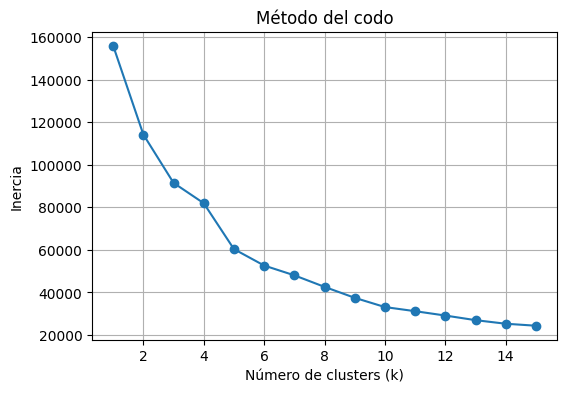

Grafica X2:



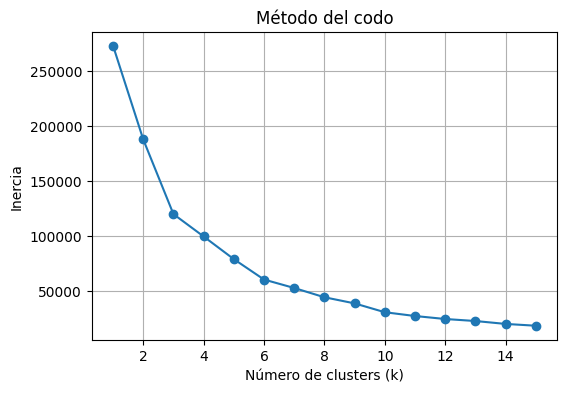

Grafica X3:



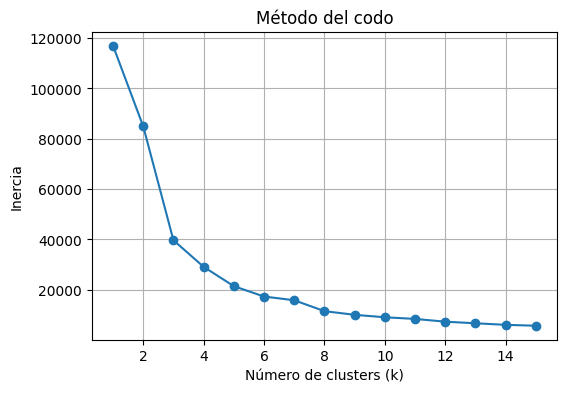

In [18]:
#METODO DEL CODO PARA SABER QUE NUMERO DE CLUSTERS USAR
print("Grafica X1:\n")
graficar_elbow(X1)
print("Grafica X2:\n")
graficar_elbow(X2)
print("Grafica X3:\n")
graficar_elbow(X3)

### 🤖 Aplicación de KMeans con k = 3

Luego de analizar el gráfico del método del codo, observamos que el punto donde la inercia deja de disminuir significativamente se encuentra en **k = 3**. Esto indica que formar **3 grupos** es una buena opción para representar los patrones en los datos sin sobreajustar ni perder información importante.

### 🔎 ¿Qué hacemos a continuación?

Entrenamos el algoritmo **KMeans** con **k = 3** (es decir, buscando formar 3 clusters) sobre cada uno de los tres conjuntos de variables previamente estandarizadas:

- **Primer modelo:** aplicado a las variables de atención médica ambulatoria.
- **Segundo modelo:** aplicado a las variables de internación y ocupación hospitalaria.
- **Tercer modelo:** aplicado a los resultados sanitarios.

De esta manera, obtenemos agrupamientos específicos para cada dimensión del sistema de salud, lo que nos permitirá identificar patrones o comportamientos similares entre las observaciones dentro de cada área.


In [19]:
# Entrenamiento de KMeans con k=3
first_kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
first_kmeans.fit(X1)
second_kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
second_kmeans.fit(X2)
third_kmeans = KMeans(n_clusters=3, random_state=0, n_init='auto')
third_kmeans.fit(X3)

# Aplicar fit_predict para obtener las etiquetas de cluster
labels_first = first_kmeans.fit_predict(X1)
labels_second = second_kmeans.fit_predict(X2)
labels_third = third_kmeans.fit_predict(X3)

In [20]:
from sklearn.metrics import silhouette_score

print('Silhouette score (KMeans - X1):', silhouette_score(X1, labels_first))
print('Silhouette score (KMeans - X2):', silhouette_score(X2, labels_second))
print('Silhouette score (KMeans - X3):', silhouette_score(X3, labels_third))

Silhouette score (KMeans - X1): 0.8788630884663108
Silhouette score (KMeans - X2): 0.8488021714586098
Silhouette score (KMeans - X3): 0.9268671168742857


In [21]:
df['cluster_X1'] = labels_first
df.groupby('cluster_X1')[columnas_X1].mean()

,consultas_medicas,consultas_odontologicas,consultas_paramedicas,interconsultas
cluster_X1,,,,
0,21008.813843,1743.105335,2875.972103,45.702210
1,280925.442043,14063.806483,34135.055529,11574.935167
2,69180.950724,238866.520833,4723.412232,304.197917


In [22]:
df['cluster_X2'] = labels_second
df.groupby('cluster_X2')[columnas_X2].mean()

,dias_camas_disponible,promedio_camas_disponibles,pacientes_dias,porcentaje_ocupacion,dias_estadia,promedio_dias_estadia,giro_de_camas
cluster_X2,,,,,,,
0,267.852850,0.748292,115.279866,1.400101,77.295158,0.860984,0.552486
1,267858.300971,746.203883,229873.834951,85.582524,273839.883495,243.582524,20.990291
2,28072.888605,77.536115,20308.549301,76.180476,18703.851407,273.559536,40.374336


In [23]:
df['cluster_X3'] = labels_third
df.groupby('cluster_X3')[columnas_X3].mean()

,egresos,defunciones,tasa_mortalidad_hospitalaria
cluster_X3,,,
0,174.087138,4.644494,0.662842
1,9905.930070,353.660839,4.244755
2,8.593478,6.019565,77.010870


### 🏷️ Etiquetas y centroides de los clusters

Una vez entrenado el modelo KMeans con **k = 3**, obtenemos dos elementos clave para cada conjunto de datos:

##### 🔹 1. Etiquetas (labels)

Cada observación (por ejemplo, una región, hospital o unidad analizada) es asignada a uno de los **3 grupos formados por KMeans**. Esa asignación se representa mediante una **etiqueta numérica (0, 1 o 2)**, que indica a qué cluster pertenece cada observación.

Estas etiquetas nos permiten:

- Saber **cuáles observaciones están agrupadas entre sí**.
- Analizar patrones comunes dentro de cada grupo.

##### 🔹 2. Centroides

Cada grupo tiene un **centroide**, que es el punto medio (promedio) de todas las observaciones asignadas a ese grupo, considerando todas las variables.

Los centroides son útiles para:

- Describir el **perfil promedio** de cada cluster.
- Comparar los clusters entre sí y entender sus diferencias principales.

Al tener los labels y los centroides para cada uno de los tres conjuntos (atención ambulatoria, internación, y resultados), podemos **analizar y caracterizar los grupos detectados en cada dimensión del sistema de salud**.


In [24]:
# Etiquetas y centroides
labels_first = first_kmeans.labels_
centroids_first = first_kmeans.cluster_centers_
labels_second = second_kmeans.labels_
centroids_second = second_kmeans.cluster_centers_
labels_third = third_kmeans.labels_
centroids_third = third_kmeans.cluster_centers_

### 📊 Analizamos la matriz de correlación de variables escaladas para X1

La matriz de correlación es una herramienta clave para interpretar y optimizar el análisis de clustering. Nos permite:

#### 🔗 Entender relaciones entre variables
Nos muestra si dos variables están relacionadas linealmente (positiva, negativa o sin relación). Esto ayuda a comprender el comportamiento conjunto de las variables en el dataset.

#### 📉 Detectar redundancia (multicolinealidad)
Si dos variables están muy correlacionadas, aportan información similar. Esto puede influir en KMeans al darle más peso a esa información, por lo que en algunos casos conviene eliminar variables redundantes.

#### 🧩 Interpretar gráficos de dispersión
La correlación explica por qué ciertos gráficos muestran tendencias (o no). Por ejemplo, si dos variables no están correlacionadas, los puntos estarán más dispersos, lo que puede resaltar mejor los clusters.

#### 🎯 Elegir variables para visualización
Permite seleccionar pares de variables con baja o alta correlación para explorar visualmente los clusters y detectar características distintivas.

#### ⚖️ Evaluar el efecto del escalado
Aunque el escalado no cambia la correlación, usar variables estandarizadas asegura que KMeans se enfoque en la forma de los datos y no en sus magnitudes originales.


                         consultas_medicas  consultas_odontologicas  \
consultas_medicas                 1.000000                 0.163373   
consultas_odontologicas           0.163373                 1.000000   
consultas_paramedicas             0.458630                 0.097570   
interconsultas                    0.281079                 0.081919   

                         consultas_paramedicas  interconsultas  
consultas_medicas                     0.458630        0.281079  
consultas_odontologicas               0.097570        0.081919  
consultas_paramedicas                 1.000000        0.233986  
interconsultas                        0.233986        1.000000  


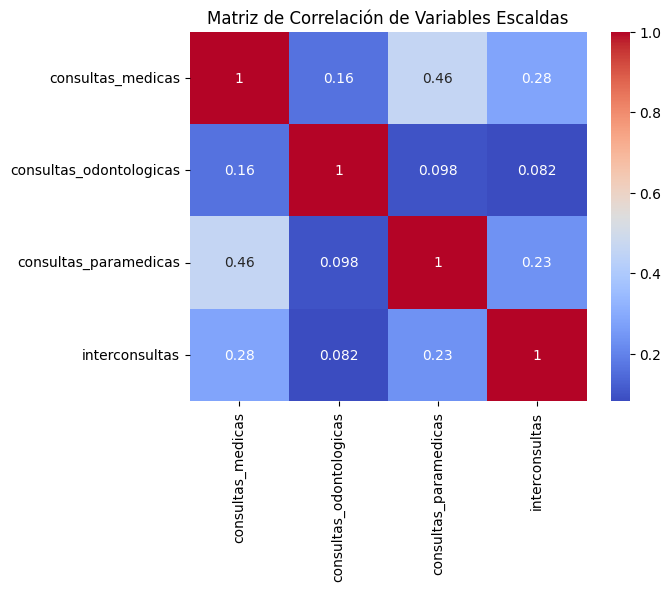

In [25]:
correlation_matrix = df[columnas_X1].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación de Variables Escaldas')
plt.show()

### 🧮 Graficamos consultas_medicas vs consultas_odontologicas y consultas_paramedicas vs interconsultas en 2D

#### 📊 ¿Por qué graficamos estos pares de variables?

Seleccionamos los pares `consultas_medicas vs consultas_odontologicas` y `consultas_paramedicas vs interconsultas` para visualizar los resultados del clustering por las siguientes razones clave:

#### 🔹 Representan dimensiones relevantes del espacio de clustering

Estas cuatro variables forman el espacio original de 4 dimensiones en el que se aplicó KMeans. Al graficarlas en pares, reducimos la dimensión a 2D para **entender visualmente cómo se separan los clusters**.


#### 📌 `consultas_medicas` vs `consultas_odontologicas`

- Son dos tipos fundamentales de atención ambulatoria.
- Según la matriz de correlación, **consultas_odontologicas está poco correlacionada** con las otras variables, por lo que aporta una dimensión única.
- Este gráfico permite detectar clusters que se caracterizan por un alto uso odontológico, como el **Cluster 2** en nuestro análisis.

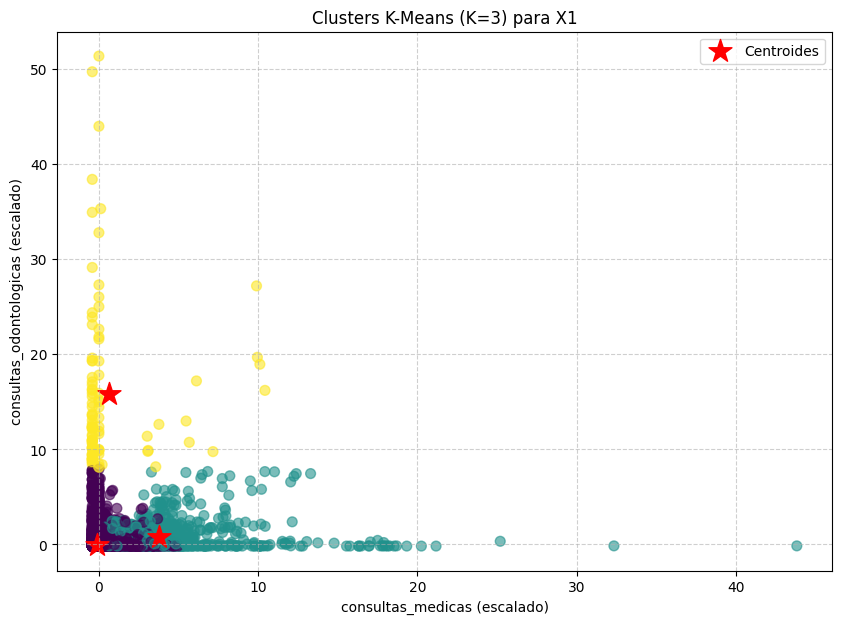

In [26]:
# Graficar si hay al menos 2 dimensiones
if X1.shape[1] >= 2:
    plt.figure(figsize=(10, 7))

    # Gráfico de los puntos del cluster
    plt.scatter(X1[:, 0], X1[:, 1], c=labels_first, cmap='viridis', s=50, alpha=0.6)

    # Etiquetas de ejes basadas en los nombres de columnas reales
    plt.xlabel(f'{columnas_X1[0]} (escalado)')
    plt.ylabel(f'{columnas_X1[1]} (escalado)')
    plt.title('Clusters K-Means (K=3) para X1')

    # Graficar centroides si hay al menos 2 dimensiones
    if centroids_first.shape[1] >= 2:
        plt.scatter(
            centroids_first[:, 0],
            centroids_first[:, 1],
            s=300,
            c='red',
            marker='*',
            label='Centroides'
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


##### ✅ Conclusión del gráfico: `consultas_medicas` vs `consultas_odontologicas`

Este gráfico permite identificar claramente tres grupos de pacientes según su perfil de uso de servicios ambulatorios:

- 🟣 **Cluster violeta/oscuro:** pacientes con **bajo uso** de ambos tipos de consultas. Sugiere la existencia de una gran base de usuarios con necesidades mínimas o esporádicas. Esto podría indicar oportunidades para campañas de salud preventiva dirigidas a fomentar un mayor uso de servicios básicos o para optimizar la asignación de recursos a centros que manejan este volumen.
- 🟢 **Cluster verde azulado:** pacientes con **alto uso de consultas médicas** y **bajo uso odontológico**.
- 🟡 **Cluster amarillo:** pacientes con **uso intensivo de consultas odontológicas**, y un uso más **variable** de consultas médicas.

📍 Los **centroides** indican el punto promedio de cada cluster y nos ayudan a visualizar cómo se diferencian en este plano.

Esto implica la necesidad de **estrategias de comunicación y servicios personalizadas** para cada grupo, asegurando que los recursos odontológicos estén disponibles para el primer grupo y que la atención médica general sea accesible y eficiente para el segundo.


#### 📌 `consultas_paramedicas` vs `interconsultas`

- Representan **servicios especializados y coordinación médica**.
- Aunque no están fuertemente correlacionadas, reflejan aspectos más complejos de la atención.
- Este gráfico es clave para visualizar diferencias marcadas en el uso de estos servicios, como la **gran separación de clusters en el eje de interconsultas** (por ejemplo, Cluster 2 con valores muy altos).
- Sirve para validar lo que indican los centroides: perfiles muy distintos entre los grupos.

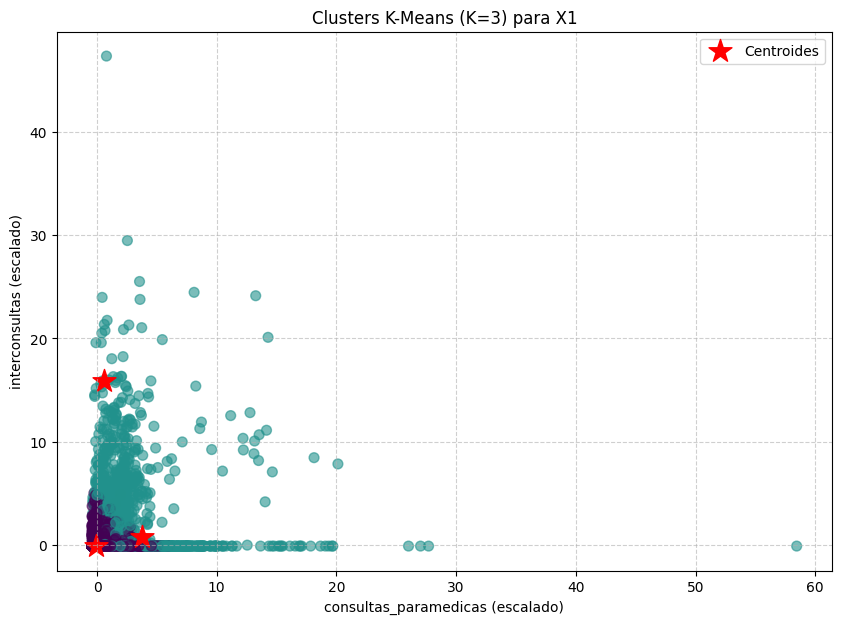

In [27]:
# Graficar si hay al menos 2 dimensiones
if X1.shape[1] >= 2:
    plt.figure(figsize=(10, 7))

    # Gráfico de los puntos del cluster
    plt.scatter(X1[:, 2], X1[:, 3], c=labels_first, cmap='viridis', s=50, alpha=0.6)

    # Etiquetas de ejes basadas en los nombres de columnas reales
    plt.xlabel(f'{columnas_X1[2]} (escalado)')
    plt.ylabel(f'{columnas_X1[3]} (escalado)')
    plt.title('Clusters K-Means (K=3) para X1')

    # Graficar centroides si hay al menos 2 dimensiones
    if centroids_first.shape[1] >= 2:
        plt.scatter(
            centroids_first[:, 0],
            centroids_first[:, 1],
            s=300,
            c='red',
            marker='*',
            label='Centroides'
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


##### ✅ Conclusión del gráfico: `consultas_paramedicas` vs `interconsultas`

Este gráfico revela tres perfiles bien diferenciados en el uso de atención especializada y coordinación médica:

- 🟣 **Cluster violeta/oscuro:** grupo más numeroso, con **muy baja utilización** de servicios paramédicos e interconsultas. Puede reflejar barreras de acceso o falta de detección de necesidades que justifiquen derivaciones.

- 🟢 **Cluster verde azulado:** presenta **uso moderado de consultas paramédicas** y **bajo uso de interconsultas**, indicando un nivel intermedio de complejidad en la atención.

- 🟡 **Cluster amarillo:** muestra una **alta demanda** tanto de consultas paramédicas como de interconsultas, lo que sugiere pacientes con **necesidades complejas y multidisciplinarias**.


### 🧮 Graficamos consultas_medicas vs consultas_paramedicas vs interconsultas en 3D

Para representar los resultados del clustering de atención ambulatoria (X1), elegimos graficar en 3D las siguientes tres variables escaladas:

- **`consultas_medicas`**: Representa la atención básica general que reciben los pacientes. Es uno de los principales indicadores del uso del sistema de salud.
- **`consultas_paramedicas`**: Incluye servicios como psicología, kinesiología o nutrición. Refleja necesidades complementarias de salud.
- **`interconsultas`**: Indica derivaciones entre profesionales o especialidades. Se asocia a mayor complejidad y coordinación del sistema de atención.

#### 🧠 Justificación de la elección

Elegimos este trío porque permite representar distintos niveles del sistema de atención ambulatoria:

- Desde **la entrada al sistema (consultas médicas)**,
- pasando por **la ampliación del abordaje (consultas paramédicas)**,
- hasta **la derivación a otros especialistas (interconsultas)**.

Esta combinación nos permite visualizar de forma más clara si los clusters identificados reflejan **perfiles de baja, media o alta complejidad** en la atención, lo que no siempre se aprecia en los gráficos 2D.

Además, estas variables mostraron **baja a moderada correlación entre sí** en la matriz de correlación, por lo que su representación en un espacio tridimensional es informativa y no redundante.


In [28]:
print(centroids_first.shape)
print(centroids_first[:, [0, 2, 3]])
print(X1[:, [0, 2, 3]].max(axis=0))

(3, 4)
[[-0.10313596 -0.09117055 -0.09340681]
 [ 3.77947657  3.38162866  3.47685539]
 [ 0.61645534  0.11407503 -0.01335834]]
[43.83701296 58.45287845 47.3231076 ]


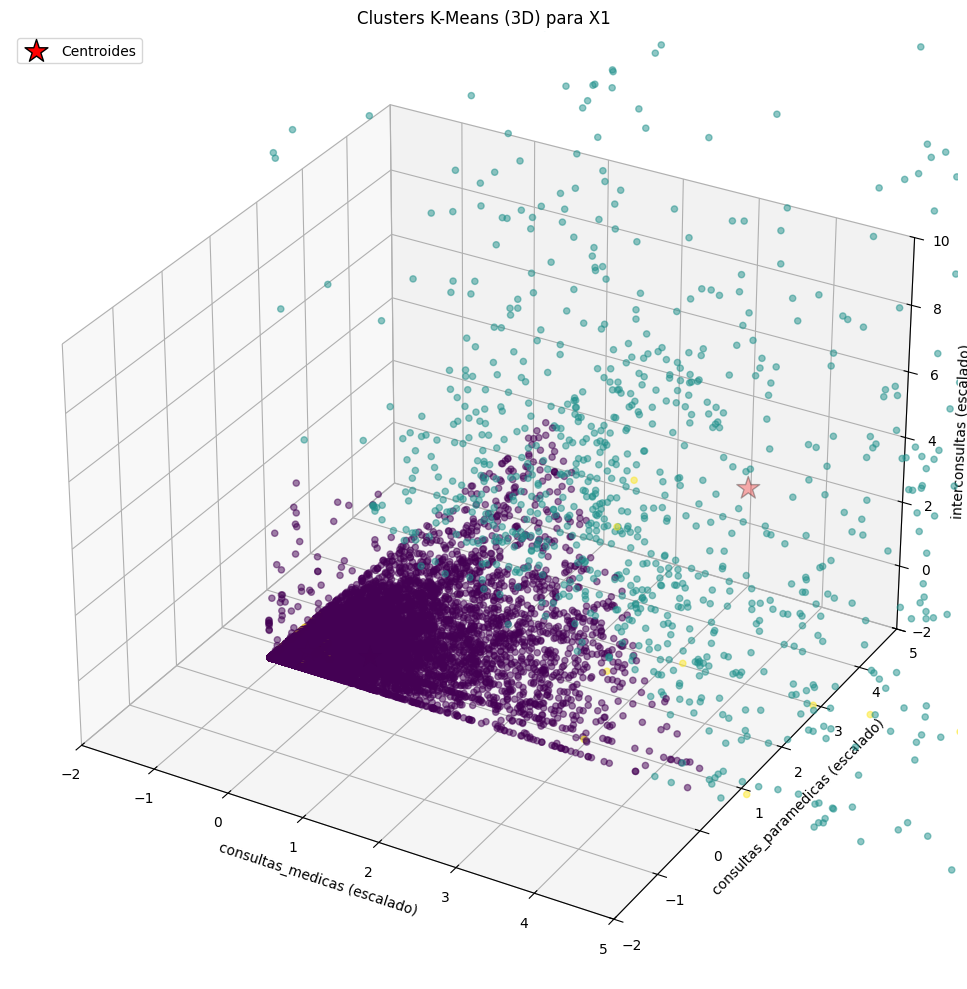

In [29]:
if X1.shape[1] == 4:
    from mpl_toolkits.mplot3d import Axes3D
    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Scatter de puntos
    ax.scatter(X1[:, 0], X1[:, 2], X1[:, 3], c=labels_first, cmap='viridis',
               marker='o', s=20, alpha=0.5)

    # Centroides en rojo
    ax.scatter(centroids_first[:, 0], centroids_first[:, 2], centroids_first[:, 3],
               s=300, c='red', marker='*', edgecolor='black', label='Centroides', zorder=10)

    # Etiquetas
    ax.set_title('Clusters K-Means (3D) para X1')
    ax.set_xlabel(f'{columnas_X1[0]} (escalado)')
    ax.set_ylabel(f'{columnas_X1[2]} (escalado)')
    ax.set_zlabel(f'{columnas_X1[3]} (escalado)')
    ax.legend()

    # ZOOM en el área donde están los centroides
    ax.set_xlim(-2, 5)
    ax.set_ylim(-2, 5)
    ax.set_zlim(-2, 10)

    plt.tight_layout()
    plt.show()


#### 🛠️ Ajuste del gráfico 3D para visualizar centroides

##### ❓ Problema inicial

Al graficar los resultados del clustering K-Means en 3D con las variables escaladas `consultas_médicas`, `consultas_paramédicas` e `interconsultas`, notamos que **los centroides no se visualizaban correctamente**. Esto se debía a que:

- La mayoría de los datos escalados (`X1`) tienen valores **mucho más altos** que los valores promedio de los centroides.
- Como los centroides están ubicados cerca del origen (por ejemplo: 2.5, 2.1, 0.3), en un gráfico con valores que llegan hasta 40, 50 o más, **quedan visualmente “aplanados”** y casi invisibles.

##### 🔍 Solución aplicada

Para resolverlo, **restringimos manualmente los límites de los ejes X, Y y Z** para hacer **zoom en la región donde están los centroides y la mayoría de los puntos densos** del dataset.

```python
ax.set_xlim(-2, 5)
ax.set_ylim(-2, 5)
ax.set_zlim(-2, 10)


### 🔍 Pairplot

Usamos un **pairplot** para visualizar cómo se distribuyen y se separan los clusters generados por KMeans en el conjunto de variables de atención ambulatoria (`X1`).

### 🧠 Para hacerlo:

1. Creamos un **DataFrame** con los datos ya escalados y le agregamos la columna `cluster`, que indica a qué grupo pertenece cada observación.

2. Con `seaborn.pairplot`, graficamos todas las combinaciones posibles de pares de variables (`consultas_medicas`, `consultas_odontologicas`, etc.) y coloreamos los puntos según el cluster asignado.

3. En la diagonal del gráfico se muestra la **distribución individual** de cada variable (en este caso usando curvas KDE — estimación de densidad).

### 🎯 ¿Para qué sirve?

- Permite **ver gráficamente cómo se separan los clusters** en diferentes combinaciones de variables.
- Ayuda a identificar **qué variables contribuyen más a la separación** entre grupos.
- Es útil para validar si los clusters definidos por KMeans tienen **formas y límites claros** o si se solapan.

En resumen, el pairplot ofrece una visión global e intuitiva de cómo se comportan los clusters en todas las dimensiones del conjunto de datos analizado.

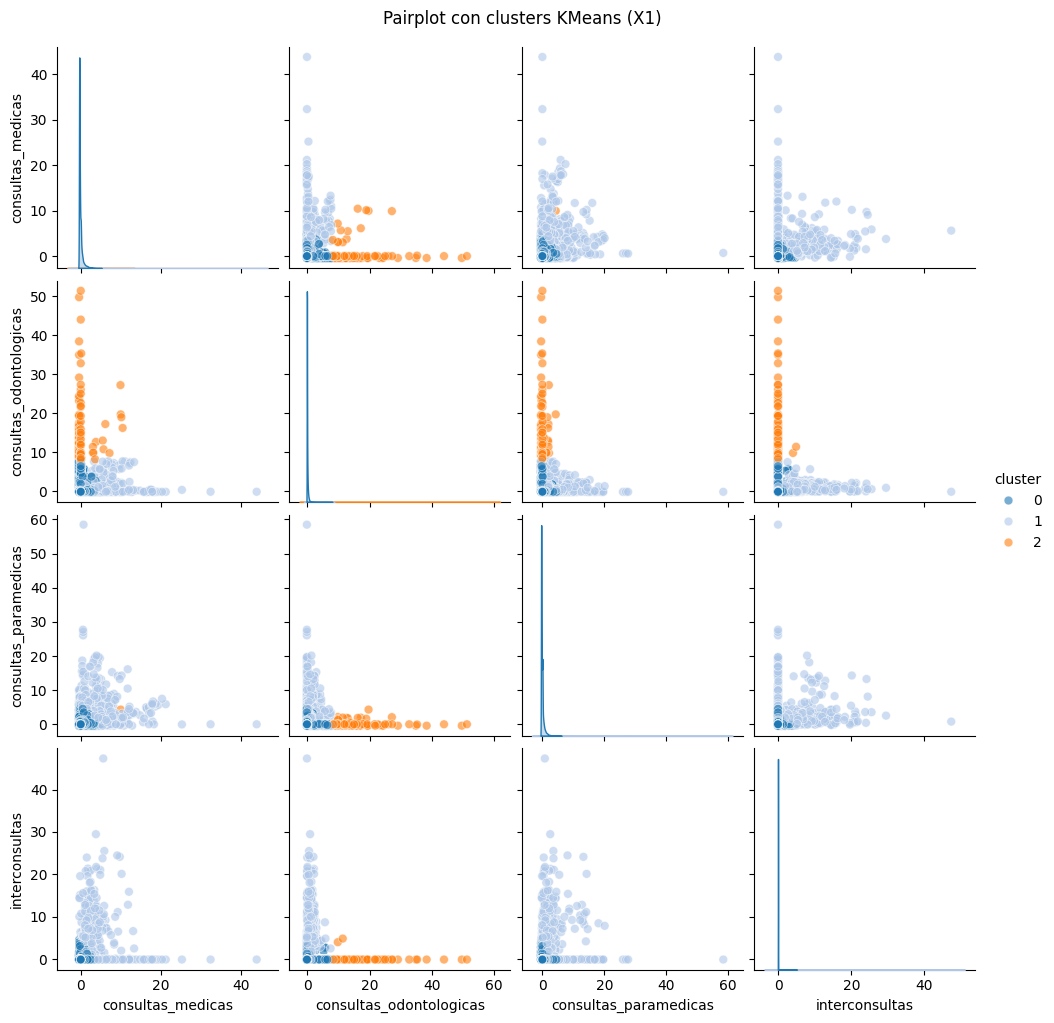

In [30]:
import seaborn as sns
import pandas as pd

# Primero, armamos un DataFrame con los datos escalados y la etiqueta cluster
df_pair = pd.DataFrame(X1, columns=columnas_X1)
df_pair['cluster'] = labels_first  # etiquetas que te dio KMeans

# Hacemos el pairplot coloreando por cluster
sns.pairplot(df_pair, hue='cluster', palette='tab20', diag_kind='kde', plot_kws={'alpha':0.6, 's':40})
plt.suptitle("Pairplot con clusters KMeans (X1)", y=1.02)
plt.show()

#### 🔍 Análisis del Pairplot para K-Means (K=3)

El **pairplot** extiende la comprensión de la segmentación realizada por K-Means (K=3) a través de todas las combinaciones de las variables en el conjunto `X1`:  
- `consultas_medicas`  
- `consultas_odontologicas`  
- `consultas_paramedicas`  
- `interconsultas`

Las **distribuciones univariadas** en la diagonal y las **relaciones bivariadas** en los paneles fuera de la diagonal revelan la coherencia de los clusters:

- **Cluster 0 (Azul claro)**: Se mantiene consistentemente como el grupo de **baja utilización** en todas las dimensiones, con puntos densamente agrupados cerca del origen en todos los gráficos de dispersión. Este cluster está notablemente **bien diferenciado** de los otros dos.

- **Cluster 1 (Naranja)**: Muestra un perfil de uso **más generalizado** de servicios médicos y paramédicos, con una tendencia a tener más `consultas_medicas` e `interconsultas`, pero también cierto **solapamiento con el Cluster 2** en algunas dimensiones.

- **Cluster 2 (Rojo)**: Aunque a veces menos denso, este cluster emerge por **valores más altos en `consultas_odontologicas` y `consultas_paramedicas`**, lo que sugiere un perfil de usuario más enfocado en estas especialidades, aunque también presenta consultas médicas e interconsultas.

Si bien los Clusters 1 y 2 muestran cierto grado de superposición en algunas vistas bidimensionales, el **pairplot confirma que K-Means ha identificado tres perfiles de pacientes distintos** basados en la totalidad de sus patrones de atención médica ambulatoria, proporcionando una base robusta para análisis posteriores o estrategias dirigidas.


### 📋 Análisis de clusters por dependencia

Asignamos las etiquetas de cluster (`labels_first`) al DataFrame original para analizar **cómo se distribuyen los clusters según la variable `dependencia`** (por ejemplo, tipo de institución, jurisdicción, etc.).

#### 🔹 ¿Qué hacemos?

- Agregamos una nueva columna `cluster` al DataFrame original (`df`), con la etiqueta asignada por KMeans.
- Creamos una copia (`df_clustered`) para trabajar sin modificar el original.
- Usamos `pd.crosstab` para generar una **tabla de frecuencia cruzada** que muestra **cuántas observaciones de cada dependencia hay en cada cluster**.

#### 🧠 ¿Para qué sirve?

- Permite identificar si ciertos clusters están **asociados a tipos específicos de instituciones o jurisdicciones**.
- Ayuda a interpretar el perfil de cada grupo en función del contexto institucional o administrativo.
- Puede revelar patrones importantes que **no surgen solo de los datos numéricos**, como que cierto cluster está compuesto mayoritariamente por hospitales municipales o centros privados.


### 📊 Gráfico de distribución de dependencias por cluster

Después de cruzar los clusters con la variable `dependencia`, creamos un **gráfico de barras apiladas** para visualizar cómo se distribuyen los diferentes tipos de dependencia dentro de cada cluster.

#### 🔹 ¿Qué muestra el gráfico?

- El eje **X** representa los **clusters formados por KMeans**.
- El eje **Y** muestra la **cantidad de establecimientos** en cada cluster.
- Cada barra está **apilada por tipo de dependencia** (por ejemplo, nacional, provincial, municipal, privada, etc.).

#### 🧠 ¿Para qué sirve?

- Permite identificar **si ciertos tipos de instituciones están concentrados en un cluster específico**.
- Ayuda a interpretar los clusters desde un enfoque **institucional o administrativo**.
- Complementa el análisis numérico con una **dimensión cualitativa y visual**, mostrando relaciones entre los grupos descubiertos y el tipo de dependencia.

En resumen, este gráfico aporta una **visualización clara y comparativa** de cómo se relacionan los clusters con la estructura del sistema de salud.


In [31]:
df['cluster'] = labels_first
df_clustered = df.copy()
df_clustered['cluster'] = labels_first
pd.crosstab(df_clustered['cluster'], df_clustered['dependencia_id'])

dependencia_id,1,2,3
cluster,,,
0,36633,1179,67
1,560,440,18
2,66,30,0


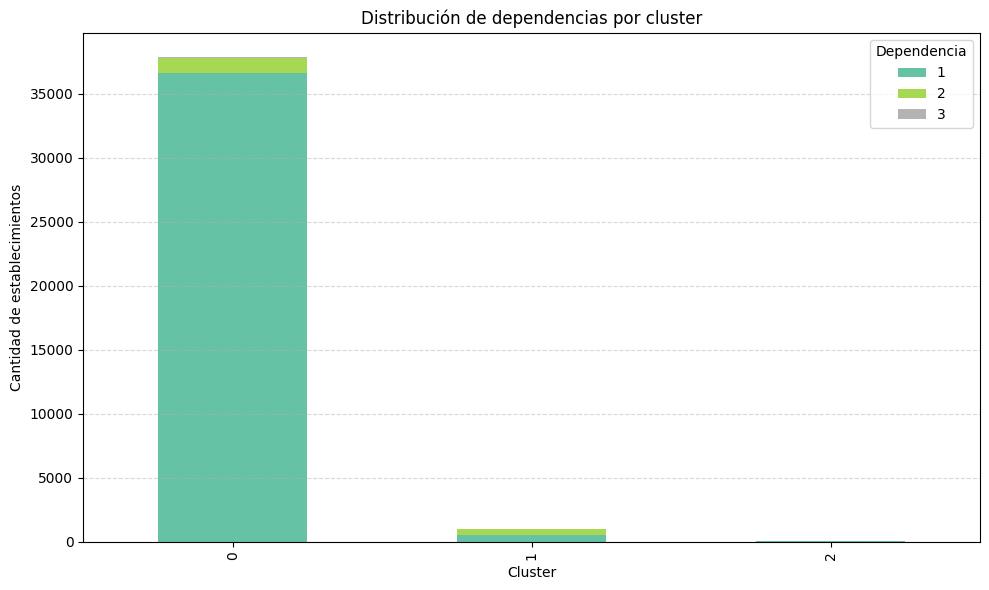

In [32]:
import matplotlib.pyplot as plt

# Crear tabla resumen
tabla = pd.crosstab(df_clustered['cluster'], df_clustered['dependencia_id'])

# Graficar
tabla.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Distribución de dependencias por cluster')
plt.xlabel('Cluster')
plt.ylabel('Cantidad de establecimientos')
plt.legend(title='Dependencia')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 📊 Análisis de la distribución de dependencias por cluster

#### 🔹 Cluster 0: el más numeroso
- Contiene la **gran mayoría de los establecimientos** (más de 35.000).
- Predominan claramente los de **dependencia Municipal** (segmento verde/aguamarina).
- Las dependencias Nacional y Provincial están presentes en una proporción **muy pequeña**.

#### 🔹 Cluster 1: tamaño intermedio
- Mucho menor que el Cluster 0, con aproximadamente **1.500 a 2.000 establecimientos**.
- La **dependencia Provincial** (segmento gris) es **la más representativa** en este grupo.
- También hay una proporción menor de establecimientos Municipales.

#### 🔹 Cluster 2: el más pequeño
- Contiene **menos de 500 establecimientos**.
- Al igual que el Cluster 1, está dominado por la **dependencia Provincial**.

#### ✅ Conclusión general
- El **Cluster 0** agrupa la mayoría de los establecimientos y está fuertemente asociado a la **gestión Municipal**.
- Los **Clusters 1 y 2**, más pequeños en tamaño, muestran una **mayor representación de dependencias Provinciales**, lo que sugiere una diferencia en el tipo de atención o complejidad que manejan.


---
### 📊 Analizamos la matriz de correlación de variables escaladas para X2
La matriz de correlación es una herramienta clave para interpretar y optimizar el análisis de clustering. Nos permite:

#### 🔗 Entender relaciones entre variables
Nos muestra si dos variables están relacionadas linealmente (positiva, negativa o sin relación). Esto ayuda a comprender el comportamiento conjunto de las variables en el dataset.

#### 📉 Detectar redundancia (multicolinealidad)
Si dos variables están muy correlacionadas, aportan información similar. Esto puede influir en KMeans al darle más peso a esa información, por lo que en algunos casos conviene eliminar variables redundantes.

#### 🧩 Interpretar gráficos de dispersión
La correlación explica por qué ciertos gráficos muestran tendencias (o no). Por ejemplo, si dos variables no están correlacionadas, los puntos estarán más dispersos, lo que puede resaltar mejor los clusters.

#### 🎯 Elegir variables para visualización
Permite seleccionar pares de variables con baja o alta correlación para explorar visualmente los clusters y detectar características distintivas.

#### ⚖️ Evaluar el efecto del escalado
Aunque el escalado no cambia la correlación, usar variables estandarizadas asegura que KMeans se enfoque en la forma de los datos y no en sus magnitudes originales.

                            dias_camas_disponible  promedio_camas_disponibles  \
dias_camas_disponible                    1.000000                    0.996538   
promedio_camas_disponibles               0.996538                    1.000000   
pacientes_dias                           0.984670                    0.981668   
porcentaje_ocupacion                     0.469635                    0.469115   
dias_estadia                             0.926517                    0.923884   
promedio_dias_estadia                    0.107923                    0.109248   
giro_de_camas                            0.260633                    0.258218   

                            pacientes_dias  porcentaje_ocupacion  \
dias_camas_disponible             0.984670              0.469635   
promedio_camas_disponibles        0.981668              0.469115   
pacientes_dias                    1.000000              0.451309   
porcentaje_ocupacion              0.451309              1.000000   
dias_estadi

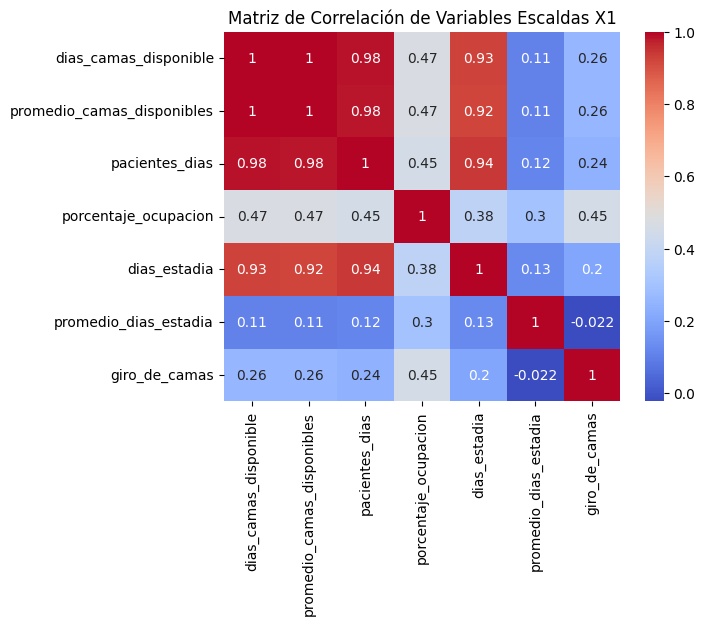

In [33]:
correlation_matrix = df[columnas_X2].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación de Variables Escaldas X1')
plt.show()

### 🧮 Graficamos dias_camas_disponibles vs pacientes_dias y promedio_camas_disponibles vs dias_camas_disponibles en 2D

#### 📌 `dias_camas_disponible` vs `promedio_camas_disponibles`
- Representan la capacidad y disponibilidad de infraestructura.
- Exhiben una correlación extremadamente fuerte (0.98), indicando que se mueven casi perfectamente juntas.

Este gráfico es **clave** para visualizar cómo los establecimientos se agrupan por su escala operativa principal, desde muy baja (Cluster 0, violeta/marrón) hasta muy alta (Cluster 2, verde/azul).

Sirve para validar que la K-Means ha capturado efectivamente la variabilidad por tamaño, mostrando centroides claramente diferenciados a lo largo de esta relación lineal. Es fundamental para categorizar y comparar la magnitud de los establecimientos.

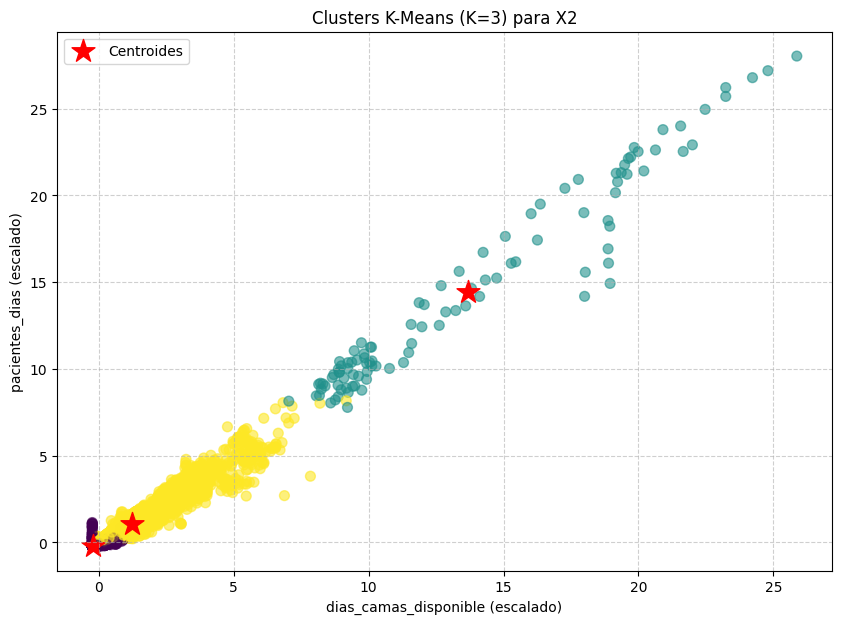

In [34]:
# Graficar si hay al menos 2 dimensiones
if X2.shape[1] >= 2:
    plt.figure(figsize=(10, 7))

    # Gráfico de los puntos del cluster
    plt.scatter(X2[:, 0], X2[:, 2], c=labels_second, cmap='viridis', s=50, alpha=0.6)

    # Etiquetas de ejes basadas en los nombres de columnas reales
    plt.xlabel(f'{columnas_X2[0]} (escalado)')
    plt.ylabel(f'{columnas_X2[2]} (escalado)')
    plt.title('Clusters K-Means (K=3) para X2')

    # Graficar centroides si hay al menos 2 dimensiones
    if centroids_second.shape[1] >= 2:
        plt.scatter(
            centroids_second[:, 0],
            centroids_second[:, 2],
            s=300,
            c='red',
            marker='*',
            label='Centroides'
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

##### 📊 Conclusión de la relación entre días de camas disponibles y dias de estadia de pacientes
Este gráfico no solo confirma la **alta correlación** entre `días de camas disponibles` y `pacientes-días`, sino que va un paso más allá al utilizar los resultados del **clustering** para segmentar esa relación en **tres tipos de establecimientos** claramente diferenciados:

##### 🔹 Cluster violeta/oscuro
- Representa establecimientos con **muy pocos días de camas disponibles** y **muy pocos pacientes-días**.
- Se trata de instituciones de **baja escala o baja actividad**.

##### 🔹 Cluster amarillo
- Agrupa establecimientos con **nivel bajo a medio** en ambas variables.
- Son instituciones de **actividad intermedia**.

##### 🔹 Cluster verde/azul
- Incluye establecimientos con **altos niveles** de días de camas disponibles y pacientes-días.
- Se asocian a instituciones de **gran escala o alta demanda**.

El clustering permite **diferenciar visualmente** los perfiles operativos de los establecimientos dentro de una relación lineal fuerte. Así, no solo vemos que existe una relación entre variables, sino **qué tipo de instituciones la recorren y cómo se agrupan**.


#### 📌 `dias_camas_disponible` vs `pacientes_dias`
- Representan la capacidad instalada y la demanda/utilización de los servicios.
- También muestran una correlación extremadamente fuerte (0.98), lo que implica que una mayor capacidad se asocia directamente con una mayor actividad de pacientes.
- Este gráfico es **clave** para visualizar la distribución de los establecimientos según su volumen de actividad, demostrando que los centros de mayor capacidad son también los que manejan un mayor número de pacientes-días.
- Sirve para validar la consistencia de los clusters: los mismos grupos identificados por disponibilidad de camas son también los que distinguen el volumen de pacientes, reforzando la idea de segmentos basados en la escala general del establecimiento.

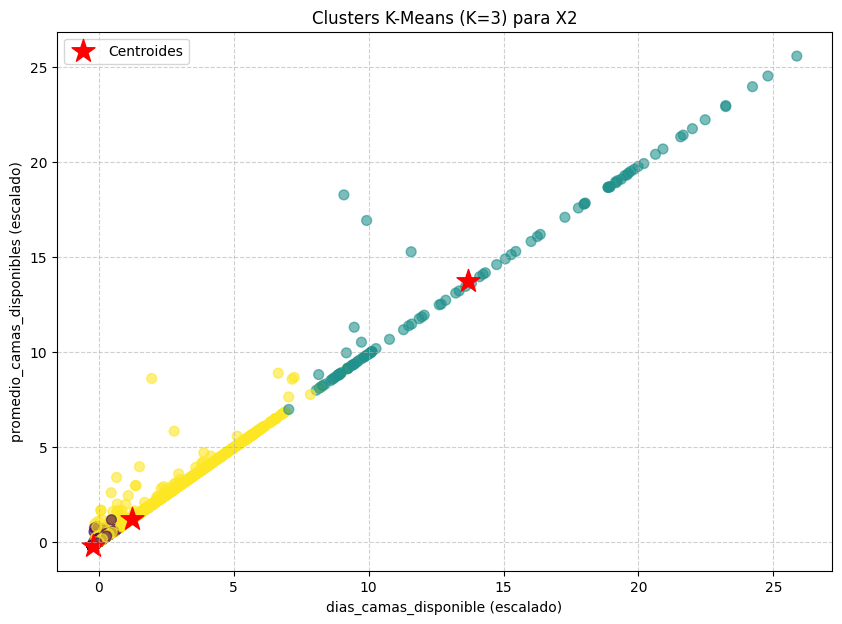

In [35]:
# Graficar si hay al menos 2 dimensiones
if X2.shape[1] >= 2:
    plt.figure(figsize=(10, 7))

    # Gráfico de los puntos del cluster
    plt.scatter(X2[:, 0], X2[:, 1], c=labels_second, cmap='viridis', s=50, alpha=0.6)

    # Etiquetas de ejes basadas en los nombres de columnas reales
    plt.xlabel(f'{columnas_X2[0]} (escalado)')
    plt.ylabel(f'{columnas_X2[1]} (escalado)')
    plt.title('Clusters K-Means (K=3) para X2')

    # Graficar centroides si hay al menos 2 dimensiones
    if centroids_second.shape[1] >= 2:
        plt.scatter(
            centroids_second[:, 0],
            centroids_second[:, 1],
            s=300,
            c='red',
            marker='*',
            label='Centroides'
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


##### 📊 Conclusión de la relación entre días de camas disponibles y promedio de camas disponibles

##### 🔹 Fuerte correlación positiva

El gráfico muestra una **relación lineal muy fuerte y positiva** entre las variables `días de camas disponibles` y `promedio de camas disponibles`. Esto significa que:

- A mayor cantidad de días con camas disponibles, mayor es el promedio diario de camas disponibles.
- Esta relación es lógica e intuitiva, ya que ambas variables reflejan la **capacidad operativa hospitalaria**.

##### 🔹 Segmentación por escala o capacidad

El uso del algoritmo **K-Means** permite ir más allá de la correlación, al identificar **tres grupos bien definidos** según la disponibilidad de camas:

- 🟣 **Cluster de baja capacidad (violeta/marrón):** Establecimientos con **muy poca disponibilidad de camas**.
- 🟡 **Cluster de mediana capacidad (amarillo):** Establecimientos con **disponibilidad intermedia**.
- 🟢 **Cluster de alta capacidad (verde/azul):** Establecimientos con **alta disponibilidad de camas**.

### 🧮 Graficamos dias_camas_disponibles vs pacientes_dias vs giro_camas en 3D

Para analizar visualmente la segmentación de establecimientos en relación a la internación y ocupación hospitalaria, seleccionamos las siguientes tres variables escaladas para graficar en 3D:

- **`dias_camas_disponible`**: Representa la **capacidad bruta** del establecimiento, es decir, cuántos días en total estuvieron disponibles las camas durante el período analizado. Es un indicador directo del tamaño operativo del hospital.

- **`pacientes_dias`**: Mide la **demanda real**, ya que refleja cuántos días de internación fueron efectivamente utilizados por los pacientes. Es clave para entender el nivel de uso del sistema.

- **`giro_de_camas`**: Indica la **rotación de camas**, o cuántas veces en promedio una cama fue ocupada por distintos pacientes en el período. Es un indicador de **eficiencia operativa**.

#### 🧠 Justificación de la elección

Esta combinación permite analizar la internación hospitalaria desde tres dimensiones complementarias:

1. **Capacidad instalada** (`dias_camas_disponible`)
2. **Utilización efectiva** (`pacientes_dias`)
3. **Eficiencia de uso** (`giro_de_camas`)

Al representar estos tres aspectos simultáneamente, se pueden identificar clusters con:

- Alta capacidad pero baja utilización (potencial infrautilización).
- Alta utilización y alta rotación (establecimientos con alta demanda y eficiencia).
- Baja capacidad y baja rotación (pequeños o menos eficientes).

Esto hace que el gráfico 3D sea **altamente informativo para segmentar establecimientos hospitalarios según su escala, demanda y desempeño**, lo cual es fundamental para la planificación de recursos y políticas de salud pública.


In [36]:
print(centroids_second.shape)
print(centroids_second[:, [0, 2, 6]])
print(X2[:, [0, 2, 6]].max(axis=0))

(3, 7)
[[-0.22491712 -0.20670213 -0.18792082]
 [13.67047733 14.45595234  0.54447029]
 [ 1.21834102  1.08133777  1.23826602]]
[25.86684704 28.03293476 32.04170582]


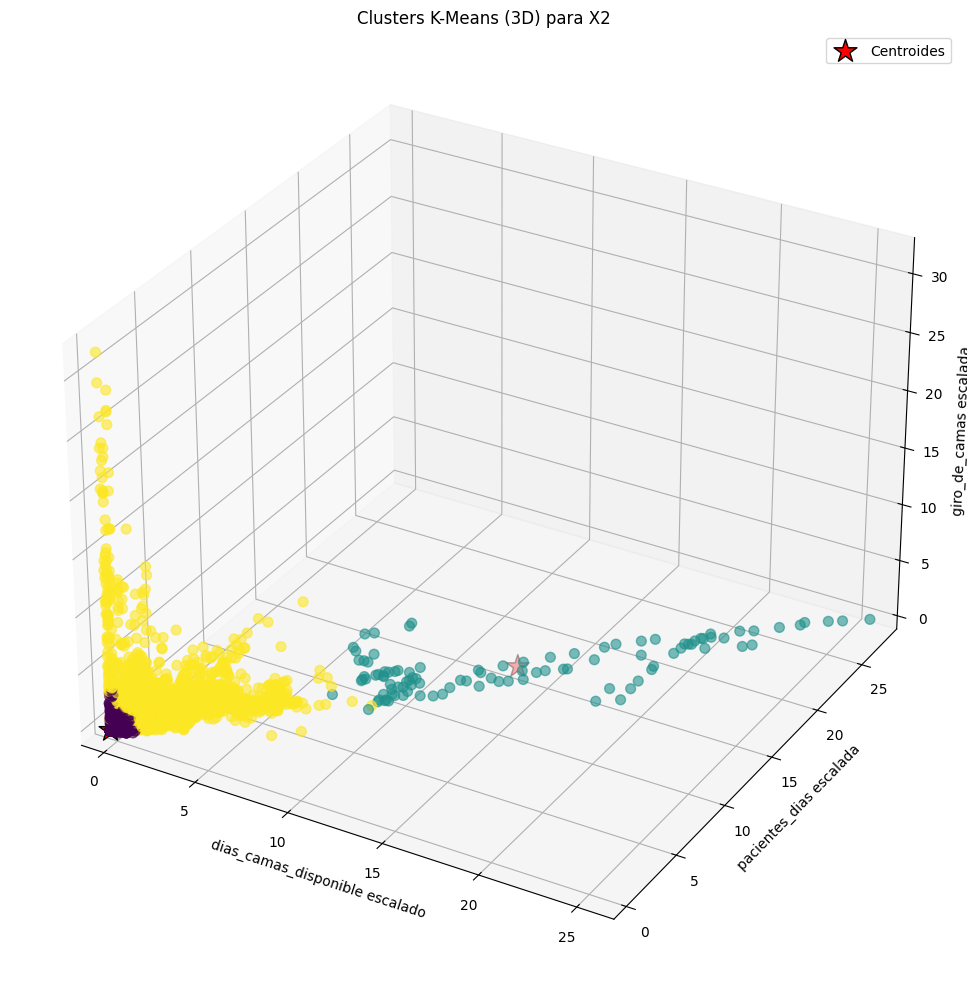

In [37]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Gráfico de puntos
ax.scatter(X2[:, 0], X2[:, 2], X2[:, 6],
           c=labels_second, cmap='viridis', marker='o', s=50, alpha=0.6)

# Centroides
ax.scatter(centroids_second[:, 0], centroids_second[:, 2], centroids_second[:, 6],
           s=300, c='red', marker='*', edgecolor='black', label='Centroides', zorder=10)

# Etiquetas
ax.set_title('Clusters K-Means (3D) para X2')
ax.set_xlabel(f'{columnas_X2[0]} escalado')
ax.set_ylabel(f'{columnas_X2[2]} escalada')
ax.set_zlabel(f'{columnas_X2[6]} escalada')
ax.legend()

# Ajuste de los límites de los ejes para que abarquen todos los datos y centroides
# Se toma el mínimo/máximo de los datos y centroides para cada eje y se le agrega un pequeño margen.
ax.set_xlim(min(X2[:, 0].min(), centroids_second[:, 0].min()) - 1,
            max(X2[:, 0].max(), centroids_second[:, 0].max()) + 1)
ax.set_ylim(min(X2[:, 2].min(), centroids_second[:, 2].min()) - 1,
            max(X2[:, 2].max(), centroids_second[:, 2].max()) + 1)
ax.set_zlim(min(X2[:, 6].min(), centroids_second[:, 6].min()) - 1,
            max(X2[:, 6].max(), centroids_second[:, 6].max()) + 1)

plt.tight_layout()
plt.show()

---
### 📊 Analizamos la matriz de correlación de variables escaladas para X3
La matriz de correlación es una herramienta clave para interpretar y optimizar el análisis de clustering. Nos permite:

#### 🔗 Entender relaciones entre variables
Nos muestra si dos variables están relacionadas linealmente (positiva, negativa o sin relación). Esto ayuda a comprender el comportamiento conjunto de las variables en el dataset.

#### 📉 Detectar redundancia (multicolinealidad)
Si dos variables están muy correlacionadas, aportan información similar. Esto puede influir en KMeans al darle más peso a esa información, por lo que en algunos casos conviene eliminar variables redundantes.

#### 🧩 Interpretar gráficos de dispersión
La correlación explica por qué ciertos gráficos muestran tendencias (o no). Por ejemplo, si dos variables no están correlacionadas, los puntos estarán más dispersos, lo que puede resaltar mejor los clusters.

#### 🎯 Elegir variables para visualización
Permite seleccionar pares de variables con baja o alta correlación para explorar visualmente los clusters y detectar características distintivas.

#### ⚖️ Evaluar el efecto del escalado
Aunque el escalado no cambia la correlación, usar variables estandarizadas asegura que KMeans se enfoque en la forma de los datos y no en sus magnitudes originales.

                               egresos  defunciones  \
egresos                       1.000000     0.809742   
defunciones                   0.809742     1.000000   
tasa_mortalidad_hospitalaria  0.035617     0.078763   

                              tasa_mortalidad_hospitalaria  
egresos                                           0.035617  
defunciones                                       0.078763  
tasa_mortalidad_hospitalaria                      1.000000  


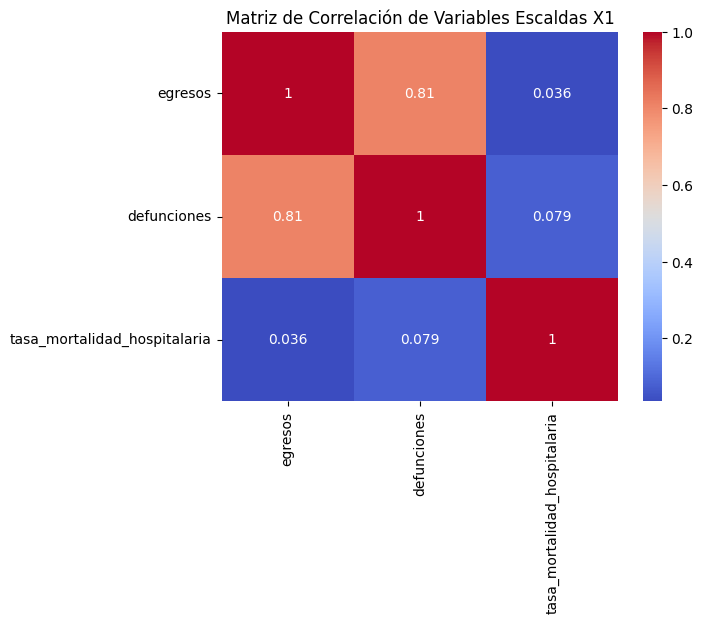

In [38]:
correlation_matrix = df[columnas_X3].corr()
print(correlation_matrix)
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlación de Variables Escaldas X1')
plt.show()

### 🧮 Graficamos egresos vs defunciones en 2D

#### 📌 `egresos` vs `defunciones`
-Representan el volumen total de pacientes que **abandonan el hospital** y el subconjunto de aquellos que **fallecen**.
- Exhiben una correlación positiva fuerte **(0.81)**, lo que indica que a mayor volumen de pacientes atendidos, mayor es el número absoluto de fallecimientos.
- Este gráfico es clave para visualizar cómo los establecimientos se agrupan en función de esta relación **volumen-fatalidad**, revelando no solo la relación esperada sino también un **cluster anómalo (violeta/oscuro)** con baja cantidad de egresos pero un número de defunciones comparativamente alto.
- Sirve para validar que la K-Means ha segmentado los datos en grupos distintos: un cluster de bajo volumen, un cluster de alto volumen normalizado y un cluster de **"baja actividad con alta defunción"**. Esto último es crucial para una investigación más profunda sobre las causas de estas elevadas defunciones en relación con el bajo número de egresos.

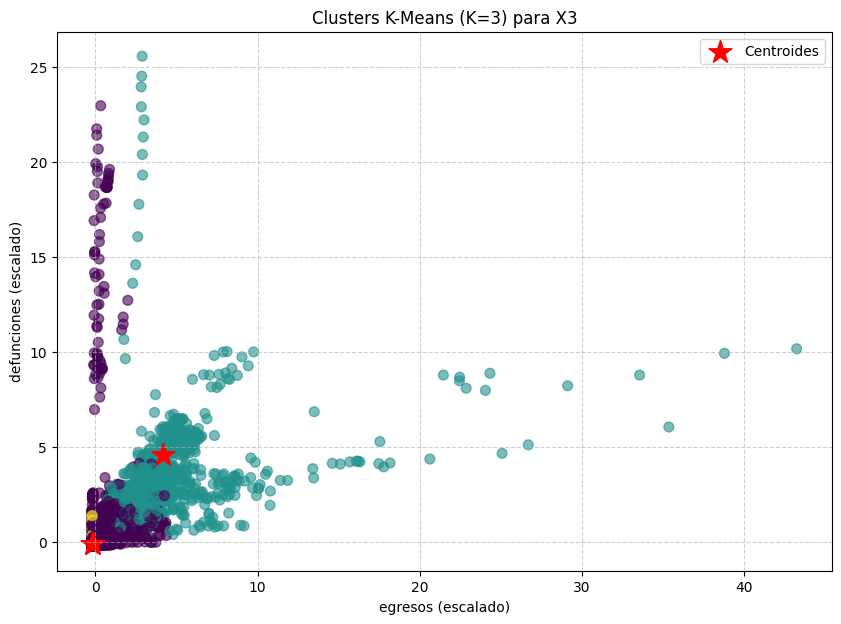

In [39]:
# Graficar si hay al menos 2 dimensiones
if X3.shape[1] >= 2:
    plt.figure(figsize=(10, 7))

    # Gráfico de los puntos del cluster
    plt.scatter(X3[:, 0], X2[:, 1], c=labels_third, cmap='viridis', s=50, alpha=0.6)

    # Etiquetas de ejes basadas en los nombres de columnas reales
    plt.xlabel(f'{columnas_X3[0]} (escalado)')
    plt.ylabel(f'{columnas_X3[1]} (escalado)')
    plt.title('Clusters K-Means (K=3) para X3')

    # Graficar centroides si hay al menos 2 dimensiones
    if centroids_third.shape[1] >= 2:
        plt.scatter(
            centroids_third[:, 0],
            centroids_third[:, 1],
            s=300,
            c='red',
            marker='*',
            label='Centroides'
        )

    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()


##### 📊 Conclusión de la relación entre egresos y defunciones

##### 🔹 Confirmación de la correlación

El gráfico sí muestra una tendencia positiva entre egresos y defunciones. Los puntos, en general, se mueven de abajo a la izquierda hacia arriba a la derecha, validando la correlación de 0.81.

##### 🔹 Ampliación (segmentación)

Lo más interesante es cómo K-Means segmenta esta relación. No es solo una línea recta como vimos con `dias_camas_disponible` y `pacientes_dias`.

- 🟡🟢 **Cluster Amarillo y Verde/Azul:** Estos dos clusters siguen la tendencia general de **"a más egresos, más defunciones"**, representando establecimientos de diferentes escalas de volumen. Son los grupos esperados.
- 🟣 **Cluster Violeta/oscuro:** Este grupo de establecimientos se distingue porque, aunque sus egresos son bajos, tienen un número de defunciones comparativamente alto o al menos muy variable para ese bajo volumen de egresos. Este cluster podría representar:

  - Establecimientos especializados en cuidados paliativos o enfermedades terminales.
  - Establecimientos que atienden casos de alta complejidad o pacientes con condiciones críticas.
  - Establecimientos con problemas de calidad o factores externos que contribuyen a una mayor mortalidad.



### 🧮 Graficamos egresos vs defunciones vs tasa de mortalidad hospitalaria en 3D

Para el análisis de los **resultados sanitarios**, seleccionamos las siguientes tres variables escaladas para graficar en 3D:

- **`egresos`**: Representa la cantidad de pacientes que fueron dados de alta o finalizaron su atención médica. Es un indicador del **volumen de atención hospitalaria** que maneja el establecimiento.

- **`defunciones`**: Indica la cantidad de muertes ocurridas en el establecimiento. Es un resultado crítico que habla del perfil de gravedad de los pacientes atendidos o de la eficiencia clínica.

- **`tasa_mortalidad_hospitalaria`**: Es un **indicador estandarizado** que relaciona defunciones con egresos. Permite comparar establecimientos independientemente de su tamaño, ajustando por volumen.

#### 🧠 Justificación de la elección

Estas tres variables cubren de forma complementaria:

1. **Volumen total de pacientes atendidos** (`egresos`)
2. **Resultados negativos absolutos** (`defunciones`)
3. **Calidad relativa de los resultados clínicos** (`tasa_mortalidad_hospitalaria`)

Graficarlas juntas permite detectar si existen clusters con:

- Alta mortalidad relativa a su volumen de atención.
- Mayor concentración de defunciones.
- Diferencias sistemáticas en el desempeño clínico entre grupos de establecimientos.

Además, como el conjunto `X3` solo contiene estas tres variables, usarlas juntas en un gráfico 3D resulta **natural, completo y fácil de interpretar visualmente**.


In [40]:
print(centroids_third.shape)
print(centroids_third[:, [0, 1, 2]])
print(X3[:, [0, 1, 2]].max(axis=0))

(3, 3)
[[-0.12514507 -0.13830964 -0.11069578]
 [ 4.1697662   4.56848876  0.2835341 ]
 [-0.19818165 -0.11976557  8.29226419]]
[43.25359082 31.30211001 10.8224768 ]


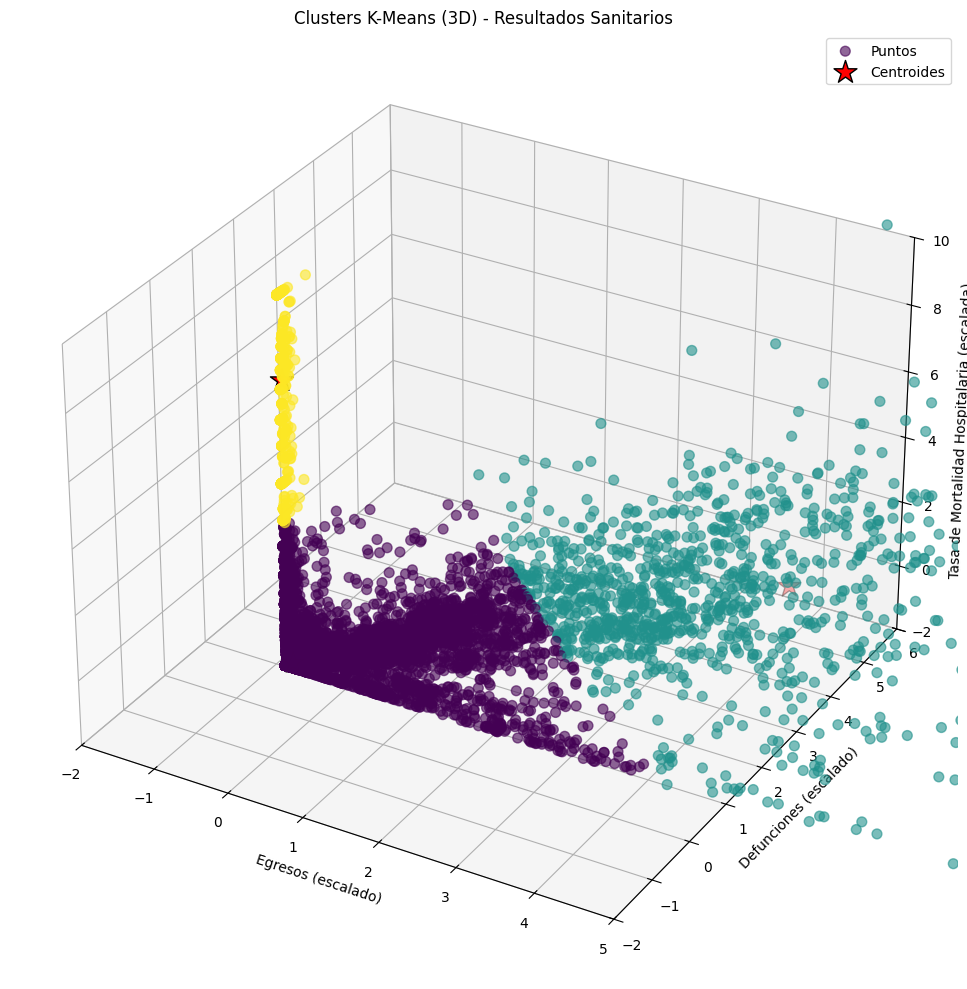

In [41]:
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Gráfico de puntos por cluster
ax.scatter(
    X3[:, 0], X3[:, 1], X3[:, 2],
    c=labels_third,
    cmap='viridis',
    marker='o',
    s=50,
    alpha=0.6,
    label='Puntos'
)
# Centroides
ax.scatter(
    centroids_third[:, 0], centroids_third[:, 1], centroids_third[:, 2],
    s=300,
    c='red',
    marker='*',
    edgecolor='black',
    label='Centroides',
    zorder=10
)
# Etiquetas de ejes
ax.set_title('Clusters K-Means (3D) - Resultados Sanitarios')
ax.set_xlabel('Egresos (escalado)')
ax.set_ylabel('Defunciones (escalado)')
ax.set_zlabel('Tasa de Mortalidad Hospitalaria (escalada)')

# Limitar para que se vea mejor
ax.set_xlim(-2, 5)
ax.set_ylim(-2, 6)
ax.set_zlim(-2, 10)

ax.legend()
plt.tight_layout()
plt.show()


##### 📊 **Conclusión de la relación entre egresos, defunciones y tasa de mortalidad**

##### 🔹 Confirmación de la correlación

Se confirma una fuerte correlación positiva entre egresos y defunciones, lo cual es esperable por volumen. En contraste, la tasa de mortalidad hospitalaria muestra una baja correlación con egresos y defunciones absolutos, lo que sugiere que esta tasa relativa se comporta de forma más independiente del volumen total de pacientes.

##### 🔹 Ampliación (segmentación)

Lo más interesante es cómo K-Means segmenta la relación entre egresos, defunciones y tasa_mortalidad_hospitalaria. No es una única tendencia, sino que se distinguen grupos con perfiles de resultados distintos:

- 🟡🟢 **Cluster Amarillo y Verde/Azul**: Estos dos clusters, que representan la mayoría de los establecimientos, siguen la tendencia esperada: a mayor volumen de egresos, mayor número de defunciones en términos absolutos. Se diferencian principalmente por la escala: uno agrupa establecimientos de alto volumen y el otro de volumen intermedio. Ambos tienen tasas de mortalidad que se mantienen dentro de rangos esperables para su volumen.

- 🟣 **Cluster Violeta/oscuro**: Este grupo se destaca por un perfil atípico: establecimientos con bajo volumen de egresos pero una tasa de mortalidad hospitalaria significativamente alta. Este cluster, aunque numéricamente menor, es crucial para identificar establecimientos que podrían requerir un análisis más profundo. Podría representar:
    - Establecimientos especializados en casos de alta complejidad o pacientes terminales, donde la proporción de defunciones sobre egresos es naturalmente más alta.
    - Posibles indicadores de problemas de calidad en la atención o factores externos que impactan la supervivencia de los pacientes atendidos en esos centros de bajo volumen.

Esta segmentación ayuda a ir más allá de las correlaciones generales y a identificar grupos de establecimientos con distintos desafíos o características en cuanto a sus resultados sanitarios.


---
## 🌐 DBSCAN: Agrupamiento basado en densidad

**DBSCAN** (*Density-Based Spatial Clustering of Applications with Noise*) es un algoritmo de clustering que agrupa puntos que se encuentran en regiones densas del espacio y separa aquellos que están aislados (considerados **ruido** o **outliers** 🧨).

A diferencia de K-Means:

- ✅ **No requiere especificar el número de clusters** con antelación.
- ✅ Puede identificar clusters de **forma irregular**.
- ❌ No funciona bien si los clusters tienen densidades muy diferentes.


#### 🧠 ¿Cómo funciona DBSCAN?

DBSCAN usa dos parámetros clave:

- `eps` ➡️ Radio de vecindad para considerar puntos vecinos.
- `min_samples` ➡️ Cantidad mínima de puntos (incluyendo el propio) necesarios para formar un cluster.

En base a estos valores, **cada punto** se clasifica como:

- 🔵 **Punto Núcleo (Core Point)**: Tiene al menos `min_samples` dentro de su vecindad (`eps`).
- 🟡 **Punto Frontera (Border Point)**: Está dentro de la vecindad de un punto núcleo, pero no tiene suficientes vecinos para ser núcleo.
- 🔴 **Punto de Ruido (Noise Point)**: No es núcleo ni frontera.

🧩 Un **cluster** es un conjunto de puntos núcleo conectados entre sí (directa o indirectamente) y los puntos frontera cercanos a ellos.


#### 🛠️ Pasos para aplicar DBSCAN

1. 🔍 **Seleccionar columnas relevantes**  
   Al igual que con K-Means, DBSCAN requiere datos **numéricos** para medir distancias entre puntos.

2. ⚖️ **Preprocesar los datos**  
   Es importante **escalar las variables** si están en diferentes rangos, ya que `eps` se calcula en el espacio de características, por lo que `StandardScaler` es una excelente opción.

3. 📏 **Determinar los parámetros `eps` y `min_samples`**  
   Este paso es **crítico** y suele requerir:
   - Prueba y error 🧪
   - Uso del **gráfico de la distancia al vecino más cercano** (k-distance plot) para estimar un buen `eps`.

4. 🤖 **Entrenar el modelo**  
   Usando `DBSCAN` de `scikit-learn`, con los valores seleccionados para `eps` y `min_samples`.

5. 🏷️ **Asignar etiquetas de cluster**  
   - Cada punto recibe una etiqueta **numérica** que representa su cluster.
   - Los puntos considerados ruido reciben la etiqueta **`-1`** ❌.

6. 📊 **Analizar y visualizar los resultados**  
   - Revisar cuántos clusters se encontraron 🔢
   - Contar cuántos puntos fueron clasificados como ruido 🧨
   - Visualizar los clusters si es posible (2D o 3D) 🎨


### 📂 Importación de herramientas

In [42]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

In [43]:
#ATENCIÓN AMBULATORIA
columnas_X1 = [
    'consultas_medicas',
    'consultas_odontologicas',
    'consultas_paramedicas',
    'interconsultas'
]
#INTERNACION Y OCUPACION HOSPITALARIA
columnas_X2 = [
    'dias_camas_disponible',
    'promedio_camas_disponibles',
    'pacientes_dias',
    'porcentaje_ocupacion',
    'dias_estadia',
    'promedio_dias_estadia',
    'giro_de_camas'
]

#RESULTADOS SANITARIOS
columnas_X3 = [
    'egresos',
    'defunciones',
    'tasa_mortalidad_hospitalaria'
]

In [44]:
scaler = StandardScaler()
X1_scaled = scaler.fit_transform(df[columnas_X1])
X2_scaled = scaler.fit_transform(df[columnas_X2])
X3_scaled = scaler.fit_transform(df[columnas_X3])

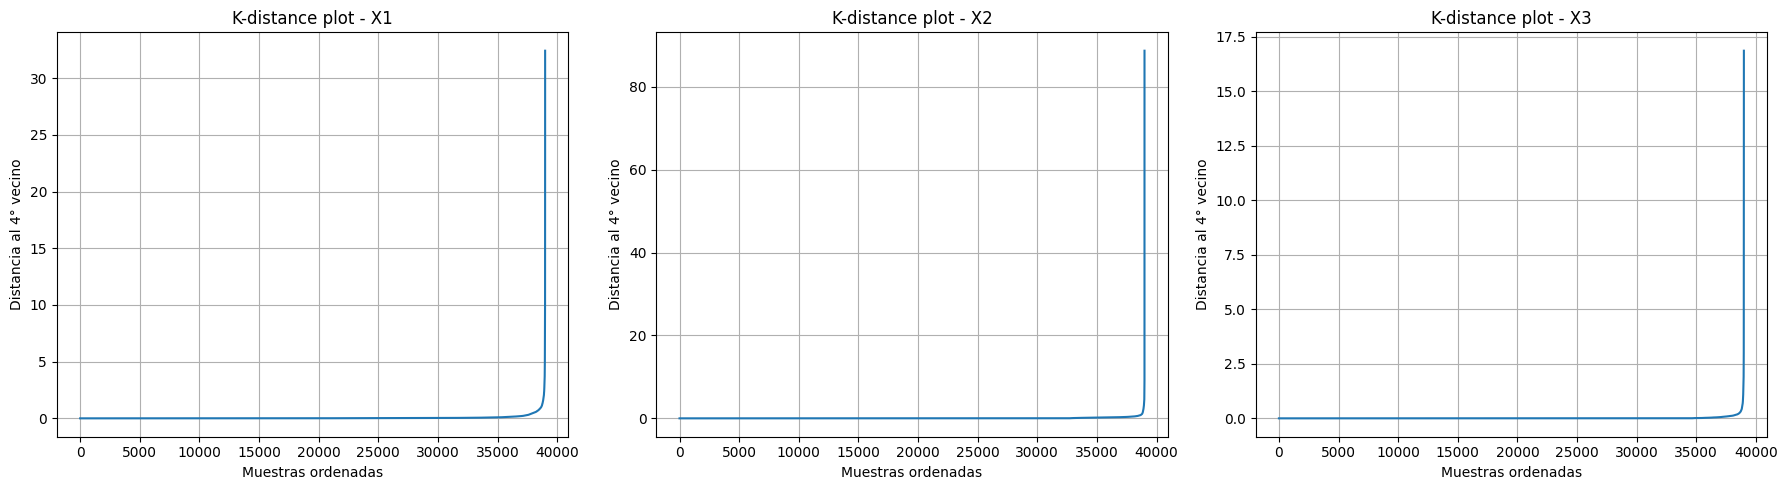

In [45]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

min_samples = 4

# ---------- X1 ----------
neighbors_X1 = NearestNeighbors(n_neighbors=min_samples)
neighbors_X1.fit(X1_scaled)
distances_X1, _ = neighbors_X1.kneighbors(X1_scaled)
distances_X1 = np.sort(distances_X1[:, -1])

# ---------- X2 ----------
neighbors_X2 = NearestNeighbors(n_neighbors=min_samples)
neighbors_X2.fit(X2_scaled)
distances_X2, _ = neighbors_X2.kneighbors(X2_scaled)
distances_X2 = np.sort(distances_X2[:, -1])

# ---------- X3 ----------
neighbors_X3 = NearestNeighbors(n_neighbors=min_samples)
neighbors_X3.fit(X3_scaled)
distances_X3, _ = neighbors_X3.kneighbors(X3_scaled)
distances_X3 = np.sort(distances_X3[:, -1])

# ---------- Gráficos ----------
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

axs[0].plot(distances_X1)
axs[0].set_title("K-distance plot - X1")
axs[0].set_xlabel("Muestras ordenadas")
axs[0].set_ylabel(f"Distancia al {min_samples}° vecino")
axs[0].grid(True)

axs[1].plot(distances_X2)
axs[1].set_title("K-distance plot - X2")
axs[1].set_xlabel("Muestras ordenadas")
axs[1].set_ylabel(f"Distancia al {min_samples}° vecino")
axs[1].grid(True)

axs[2].plot(distances_X3)
axs[2].set_title("K-distance plot - X3")
axs[2].set_xlabel("Muestras ordenadas")
axs[2].set_ylabel(f"Distancia al {min_samples}° vecino")
axs[2].grid(True)

plt.tight_layout()
plt.show()


In [46]:
from sklearn.cluster import DBSCAN

# DBSCAN para X1
dbscan_x1 = DBSCAN(eps=2.5, min_samples=4)
dbscan_x1.fit(X1_scaled) #?
labels_x1 = dbscan_x1.labels_

# DBSCAN para X2
dbscan_x2 = DBSCAN(eps=2.5, min_samples=4)
dbscan_x2.fit(X2_scaled)
labels_x2 = dbscan_x2.labels_

# DBSCAN para X3
dbscan_x3 = DBSCAN(eps=2.5, min_samples=4)
dbscan_x3.fit(X3_scaled)
labels_x3 = dbscan_x3.labels_


### 📊 Análisis de Clustering con DBSCAN (`eps = 2.5`) sobre X1, X2 y X3

In [47]:
# Para X1
n_clusters_x1 = len(set(labels_x1)) - (1 if -1 in labels_x1 else 0)
n_noise_x1 = list(labels_x1).count(-1)
print(f"X1 - Clusters encontrados: {n_clusters_x1}")
print(f"X1 - Puntos de ruido: {n_noise_x1}")

# Para X2
n_clusters_x2 = len(set(labels_x2)) - (1 if -1 in labels_x2 else 0)
n_noise_x2 = list(labels_x2).count(-1)
print(f"\nX2 - Clusters encontrados: {n_clusters_x2}")
print(f"X2 - Puntos de ruido: {n_noise_x2}")

# Para X3
n_clusters_x3 = len(set(labels_x3)) - (1 if -1 in labels_x3 else 0)
n_noise_x3 = list(labels_x3).count(-1)
print(f"\nX3 - Clusters encontrados: {n_clusters_x3}")
print(f"X3 - Puntos de ruido: {n_noise_x3}")


X1 - Clusters encontrados: 2
X1 - Puntos de ruido: 58

X2 - Clusters encontrados: 5
X2 - Puntos de ruido: 58

X3 - Clusters encontrados: 3
X3 - Puntos de ruido: 10


#### 🔍 Resultados del modelo

##### 🏥 X1 - Atención Ambulatoria
- **Cantidad de clusters encontrados:** 2
- **Puntos clasificados como ruido:** 58

DBSCAN identificó **dos grupos principales** de establecimientos según su uso de servicios ambulatorios, y un pequeño grupo de outliers que no pertenecen a ninguno.

##### 🛏️ X2 - Internación y Ocupación Hospitalaria
- **Cantidad de clusters encontrados:** 5
- **Puntos clasificados como ruido:** 58

DBSCAN segmentó los establecimientos en **cinco perfiles distintos** según su capacidad y ocupación hospitalaria, con una proporción moderada de puntos atípicos.

##### ⚰️ X3 - Resultados Sanitarios
- **Cantidad de clusters encontrados:** 3
- **Puntos clasificados como ruido:** 10

Se identificaron **tres patrones** diferenciados en los resultados sanitarios (egresos, defunciones y mortalidad), con muy pocos establecimientos considerados ruido.

### 📈 Gráfico X1: Clusters DBSCAN en el plano `consultas_médicas` vs `consultas_odontológicas` 2D

El gráfico muestra la distribución de los establecimientos en función de la cantidad de consultas médicas y odontológicas, coloreados según su pertenencia a un cluster:

- Los puntos **azules** y **marrones** representan los dos clusters principales.
- Los puntos etiquetados como **-1** son considerados **ruido** por DBSCAN: casos atípicos con patrones extremos de uso.

Este tipo de visualización permite observar la **estructura de densidad** en los datos, algo que algoritmos como KMeans no capturan tan fácilmente.

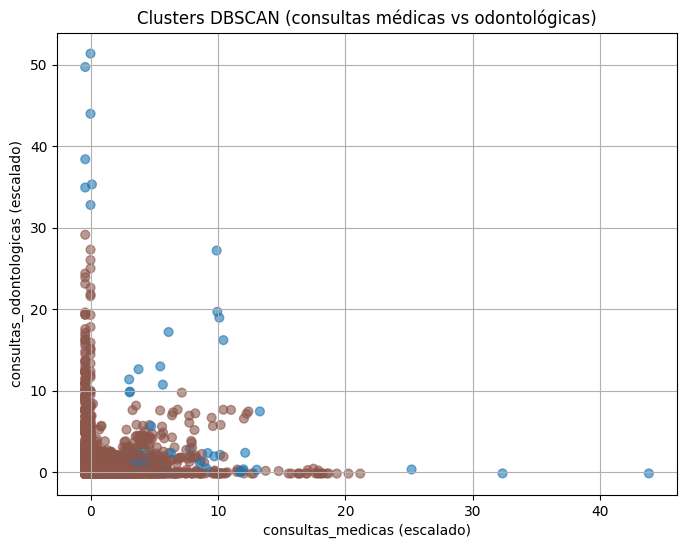

In [48]:
plt.figure(figsize=(8, 6))
plt.scatter(X1_scaled[:, 0], X1_scaled[:, 1], c=labels_x1, cmap='tab10', s=40, alpha=0.6)
plt.title("Clusters DBSCAN (consultas médicas vs odontológicas)")
plt.xlabel("consultas_medicas (escalado)")
plt.ylabel("consultas_odontologicas (escalado)")
plt.grid(True)
plt.show()

### 🧮 Promedios de variables por cluster (conjunto X1 - Atención Ambulatoria)

In [49]:
df_con_clusters_x1 = df.copy()
df_con_clusters_x1['cluster_dbscan'] = labels_x1

# Promedio por cluster de atención ambulatoria
df_con_clusters_x1.groupby('cluster_dbscan')[columnas_X1].mean().round(2)


,consultas_medicas,consultas_odontologicas,consultas_paramedicas,interconsultas
cluster_dbscan,,,,
-1,487951.56,130924.36,70256.78,24568.17
0,27171.63,2451.60,3573.12,304.85
1,300655.38,31032.12,122006.00,31486.12


### 🧠 Interpretación de los clusters

- **Cluster 0**: Representa la **gran mayoría de los establecimientos**, con uso bajo o moderado de todos los servicios ambulatorios. Perfil típico de **atención primaria o centros de baja demanda**.

- **Cluster 1**: Agrupa establecimientos con **alta utilización** de consultas médicas, odontológicas, paramédicas e interconsultas. Posibles centros de salud más complejos o con gran cobertura poblacional.

- **Cluster -1 (Ruido)**: Establecimientos con valores **extremadamente altos** en todos los indicadores. Fueron excluidos de los clusters principales por su lejanía respecto a las zonas densas del conjunto de datos. Pueden representar **casos atípicos o centros especializados**.


### 🏛️ Relación entre Clusters DBSCAN y Dependencia Administrativa

#### 🔗 Cruzar con variable `dependencia`

Analizaremos la relación entre los clusters detectados y el tipo de **dependencia administrativa** (Municipal, Provincial, Nacional) para evaluar si hay patrones estructurales que expliquen los perfiles de uso ambulatorio.


In [50]:
# Agregamos el cluster al DataFrame original
df_con_clusters_x1 = df.copy()
df_con_clusters_x1['cluster_dbscan'] = labels_x1

# Tabla cruzada
tabla_dependencia_x1 = pd.crosstab(df_con_clusters_x1['cluster_dbscan'], df_con_clusters_x1['dependencia_id'])

# Mostramos la tabla
tabla_dependencia_x1

dependencia_id,1,2,3
cluster_dbscan,,,
-1,37,13,8
0,37222,1628,77
1,0,8,0


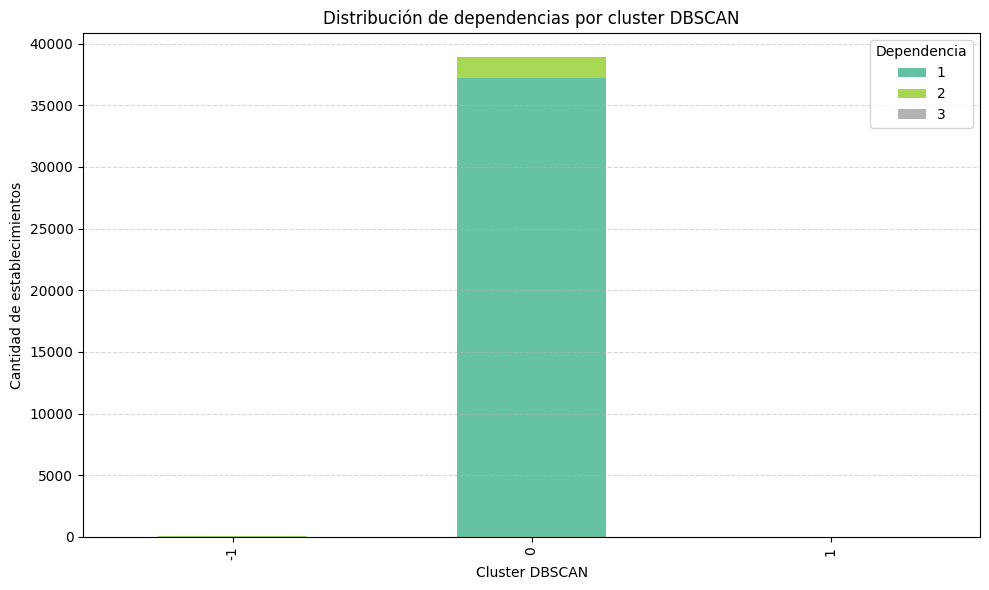

In [51]:
# Gráfico de barras apiladas
tabla_dependencia_x1.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='Set2')
plt.title('Distribución de dependencias por cluster DBSCAN')
plt.xlabel('Cluster DBSCAN')
plt.ylabel('Cantidad de establecimientos')
plt.legend(title='Dependencia')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

#### 📊 Interpretación del gráfico de barras

- **Cluster 0**:
  - Es el **más numeroso**, con más de 39.000 establecimientos.
  - Está dominado ampliamente por **dependencias Municipales**, lo que refuerza la idea de que se trata de establecimientos de **atención básica o primaria**, con baja utilización de servicios.

- **Cluster 1**:
  - Es un grupo muy pequeño, de solo **9 establecimientos**, compuesto casi exclusivamente por dependencias **Provinciales**.
  - Esto refuerza que este grupo representa **centros especializados o de mayor complejidad**, con alta utilización de consultas médicas, paramédicas e interconsultas.

- **Cluster -1 (Ruido)**:
  - Son establecimientos considerados **outliers** por DBSCAN (58 casos).
  - Aunque minoritarios, muestran una mezcla más balanceada de dependencias: 37 Municipales, 8 Nacionales y 13 Provinciales.
  - Esto sugiere que incluso dentro del "ruido", puede haber **casos extremos relevantes** a nivel institucional (por ejemplo, hospitales de gran volumen, sin importar la dependencia).

#### ✅ Conclusión general

El análisis confirma que:
- La **atención ambulatoria de baja intensidad** está altamente centralizada en establecimientos **municipales**.
- Los **establecimientos de mayor complejidad y demanda** son escasos, mayormente **provinciales**.
- Los casos extremos (ruido) abarcan distintos tipos de dependencia, y podrían representar situaciones particulares que ameritan un análisis individual.

Este cruce entre clusters y dependencia administrativa proporciona **evidencia estructural clave** para entender cómo se distribuyen los servicios de salud según su nivel de atención y gobierno.


---
### 📈 Gráfico X2: Clusters DBSCAN en el plano `pacientes_dias` vs `dias_camas_dosponibles` 2D

- Representan la capacidad instalada y la demanda/utilización de los servicios.
- También muestran una correlación extremadamente fuerte, lo que implica que una mayor capacidad se asocia directamente con una mayor actividad de pacientes.
- Este gráfico es **clave** para visualizar la distribución de los establecimientos según su volumen de actividad, demostrando que los centros de mayor capacidad son también los que manejan un mayor número de pacientes-días.

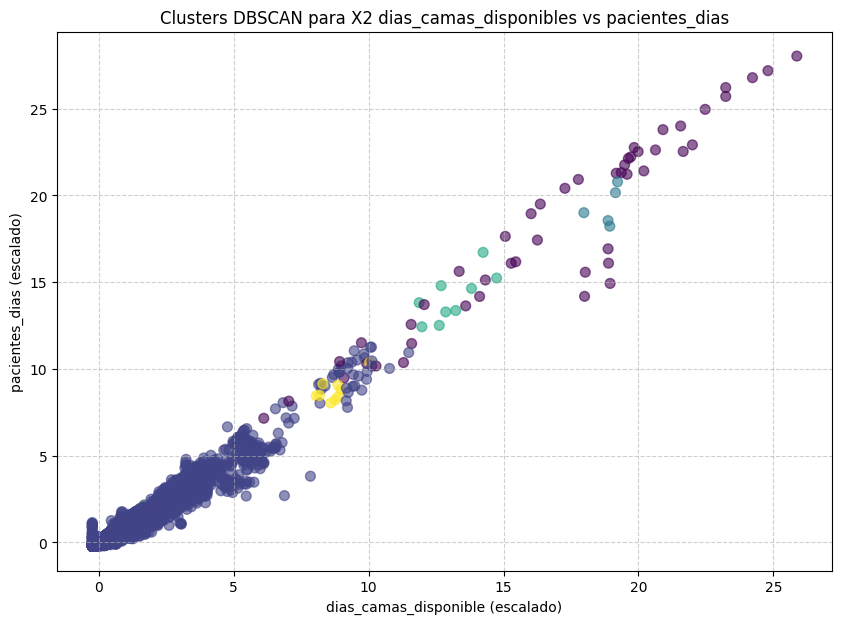

In [52]:
# Graficar si hay al menos 2 dimensiones
if X2.shape[1] >= 2:
    plt.figure(figsize=(10, 7))
    plt.scatter(X2[:, 0], X2[:, 2], c=labels_x2, cmap='viridis', s=50, alpha=0.6)
    plt.xlabel(f'{columnas_X2[0]} (escalado)')
    plt.ylabel(f'{columnas_X2[2]} (escalado)')
    plt.title('Clusters DBSCAN para X2 dias_camas_disponibles vs pacientes_dias')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

#### 📊 **Conclusión de la relación entre la capacidad de los establecimientos (dias_camas_disponibles) y la actividad de los pacientes (pacientes_dias).**

##### 🔹 Confirmación de la correlación y el cluster principal

La mayoría de los puntos se concentran en la parte inferior izquierda, formando el Cluster principal (el color más abundante). Esto confirma la **alta correlación positiva** entre `dias_camas_disponibles` y `pacientes_dias` que ya observamos en la matriz de correlación: a mayor capacidad (más días cama disponibles), generalmente hay más actividad de pacientes (más pacientes días). Este cluster representa a la vasta mayoría de establecimientos con **baja capacidad y baja actividad de internación**.

##### 🔹 Ampliación (segmentación) y puntos atípicos

Los otros clusters identificados por DBSCAN (los puntos de otros colores), aunque menos numerosos, se encuentran distribuidos en otras áreas del gráfico, principalmente a lo largo de la tendencia positiva. Estos clusters probablemente representan establecimientos con **mayor capacidad y actividad**.

Lo más interesante son los puntos dispersos (generalmente etiquetados como -1 o ruido por DBSCAN), que se alejan de las concentraciones principales. Estos puntos son **atípicos** en términos de su combinación de camas disponibles y pacientes-días. Podrían ser establecimientos con una capacidad muy alta o muy baja en relación con su actividad, o con valores extremos que los diferencian del resto. Analizar estos puntos de ruido es crucial para identificar establecimientos que operan de manera inusual en términos de internación y ocupación.

### 🧮 Grafico X2: dias_camas_disponibles vs pacientes_dias vs giro_camas en 3D

Para analizar visualmente la segmentación de establecimientos en relación a la internación y ocupación hospitalaria, seleccionamos las siguientes tres variables escaladas para graficar en 3D:

- **`dias_camas_disponible`**: Representa la **capacidad bruta** del establecimiento, es decir, cuántos días en total estuvieron disponibles las camas durante el período analizado. Es un indicador directo del tamaño operativo del hospital.

- **`pacientes_dias`**: Mide la **demanda real**, ya que refleja cuántos días de internación fueron efectivamente utilizados por los pacientes. Es clave para entender el nivel de uso del sistema.

- **`giro_de_camas`**: Indica la **rotación de camas**, o cuántas veces en promedio una cama fue ocupada por distintos pacientes en el período. Es un indicador de **eficiencia operativa**.

#### 🧠 Justificación de la elección

Esta combinación permite analizar la internación hospitalaria desde tres dimensiones complementarias:

1. **Capacidad instalada** (`dias_camas_disponible`)
2. **Utilización efectiva** (`pacientes_dias`)
3. **Eficiencia de uso** (`giro_de_camas`)

Al representar estos tres aspectos simultáneamente, se pueden identificar clusters con:

- Alta capacidad pero baja utilización (potencial infrautilización).
- Alta utilización y alta rotación (establecimientos con alta demanda y eficiencia).
- Baja capacidad y baja rotación (pequeños o menos eficientes).

Esto hace que el gráfico 3D sea **altamente informativo para segmentar establecimientos hospitalarios según su escala, demanda y desempeño**, lo cual es fundamental para la planificación de recursos y políticas de salud pública.


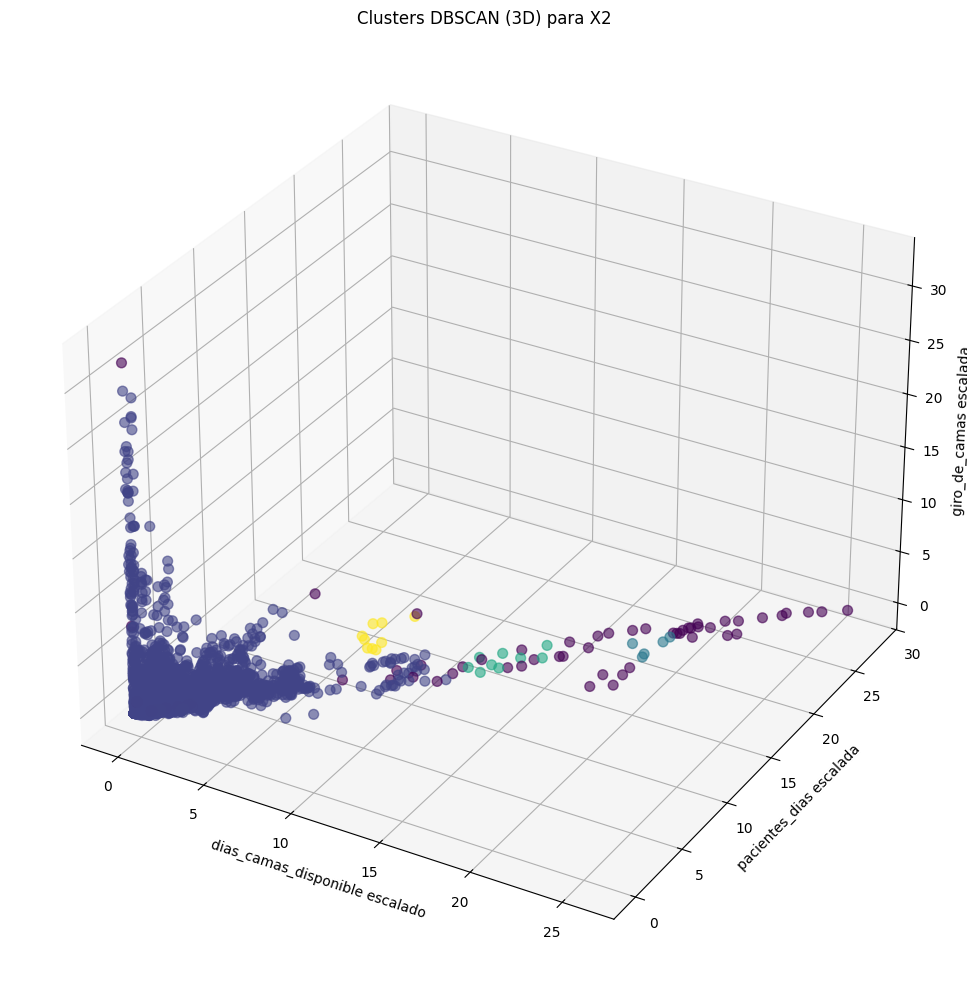

In [53]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Gráfico de puntos
ax.scatter(X2[:, 0], X2[:, 2], X2[:, 6],
           c=labels_x2, cmap='viridis', marker='o', s=50, alpha=0.6)

# Etiquetas
ax.set_title('Clusters DBSCAN (3D) para X2')
ax.set_xlabel(f'{columnas_X2[0]} escalado')
ax.set_ylabel(f'{columnas_X2[2]} escalada')
ax.set_zlabel(f'{columnas_X2[6]} escalada')

plt.tight_layout()
plt.show()

📊 **Conclusión del gráfico Clusters DBSCAN (3D) para X2: dias_camas_disponibles vs pacientes_dias vs giro_de_camas**

Este gráfico 3D nos permite visualizar la segmentación de los establecimientos hospitalarios en función de su capacidad, volumen de pacientes y eficiencia en la rotación de camas.

🔹 Confirmación de la correlación y el cluster principal.
El cluster principal (el grupo más denso) se concentra en la región de bajos valores para las tres variables. Esto confirma que la mayoría de los establecimientos tienen una capacidad limitada (dias_camas_disponibles bajos), un bajo volumen de pacientes internados (pacientes_dias bajos) y, en general, una baja rotación de camas (giro_de_camas bajo). Este cluster representa a la mayoría de establecimientos con baja capacidad y baja actividad de internación.

🔹 Ampliación (segmentación) y puntos atípicos
Los otros clusters identificados por DBSCAN (los puntos de otros colores), aunque menos numerosos, se distribuyen en áreas del gráfico con valores más altos en dias_camas_disponibles y pacientes_dias, representando establecimientos de mayor escala y actividad. La variable giro_de_camas puede variar dentro de estos clusters de mayor actividad, indicando diferentes niveles de eficiencia.

Los puntos de ruido (-1) son especialmente relevantes en este gráfico 3D se dispersan lejos de los clusters principales y podrían ser, por ejemplo:

- Establecimientos con alta capacidad pero baja ocupación (dias_camas_disponibles altos, pacientes_dias bajos).
- Establecimientos con alta ocupación y alta rotación (pacientes_dias altos, giro_de_camas altos).



---
### 📈 Gráfico X3: Clusters DBSCAN en el plano `egresos` vs `defunciones` 2D

#### 📌 `egresos` vs `defunciones`
- Representan el volumen total de pacientes que **abandonan el hospital** y el subconjunto de aquellos que **fallecen**.
- Exhiben una correlación positiva fuerte, lo que indica que a mayor volumen de pacientes atendidos, mayor es el número absoluto de fallecimientos.

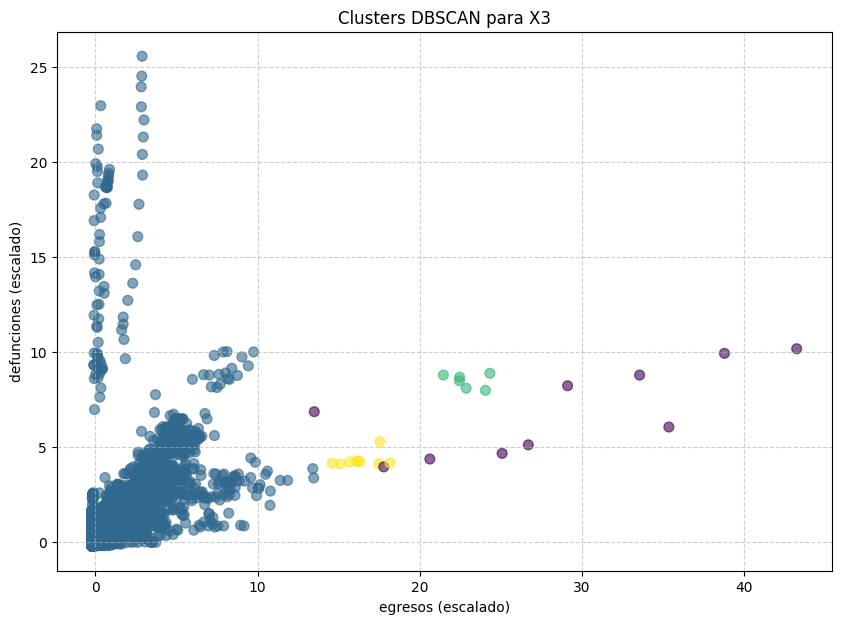

In [54]:
# Graficar si hay al menos 2 dimensiones
X2.shape[1] >= 2
plt.figure(figsize=(10, 7))
plt.scatter(X3[:, 0], X2[:, 1], c=labels_x3, cmap='viridis', s=50, alpha=0.6)
plt.xlabel(f'{columnas_X3[0]} (escalado)')
plt.ylabel(f'{columnas_X3[1]} (escalado)')
plt.title('Clusters DBSCAN para X3')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

📊 **Conclusión del gráfico Clusters DBSCAN (2D) para X3: egresos vs defunciones**

Este gráfico 2D visualiza la relación entre el volumen total de pacientes dados de alta (egresos) y el número absoluto de fallecimientos (defunciones), coloreados según los clusters identificados por DBSCAN.

🔹 Confirmación de la correlación y el cluster principal.
La mayoría de los puntos se concentran en la parte inferior izquierda del gráfico, formando el cluster principal (el grupo más denso, generalmente de un color predominante). Esto confirma la fuerte correlación positiva entre egresos y defunciones: a mayor número de pacientes dados de alta, mayor es el número absoluto de fallecimientos, lo cual es un patrón esperado por volumen. Este cluster representa a la vasta mayoría de establecimientos con bajo volumen de actividad hospitalaria y, consecuentemente, un bajo número absoluto de defunciones.

🔹 Ampliación (segmentación) y puntos atípicos.
Los otros clusters identificados por DBSCAN (los puntos de otros colores), aunque menos numerosos, se distribuyen a lo largo de la tendencia positiva de la correlación, representando establecimientos de mayor volumen de actividad. Estos clusters muestran que, dentro de la relación general, DBSCAN puede identificar grupos con diferentes escalas de operación.

Los puntos de ruido (-1) son especialmente interesantes en este gráfico 2D podrían ser:

- Establecimientos con un volumen de egresos muy alto y un número de defunciones también muy alto, que se encuentran en el extremo superior de la tendencia.
- Establecimientos con un volumen de egresos relativamente bajo pero un número de defunciones inusualmente alto para ese volumen, lo que los haría destacar por encima de la tendencia principal y podrían indicar perfiles de atención especializada en casos críticos o posibles problemas que requieren investigación.


### 📈 Gráfico X3: Clusters DBSCAN en el plano `egresos` vs `defunciones` vs `tasa_mortalidad_hospitalaria` 3D

Para el análisis de los **resultados sanitarios**, seleccionamos las siguientes tres variables escaladas para graficar en 3D:

- **`egresos`**: Representa la cantidad de pacientes que fueron dados de alta o finalizaron su atención médica. Es un indicador del **volumen de atención hospitalaria** que maneja el establecimiento.

- **`defunciones`**: Indica la cantidad de muertes ocurridas en el establecimiento. Es un resultado crítico que habla del perfil de gravedad de los pacientes atendidos o de la eficiencia clínica.

- **`tasa_mortalidad_hospitalaria`**: Es un **indicador estandarizado** que relaciona defunciones con egresos. Permite comparar establecimientos independientemente de su tamaño, ajustando por volumen.

#### 🧠 Justificación de la elección

Estas tres variables cubren de forma complementaria:

1. **Volumen total de pacientes atendidos** (`egresos`)
2. **Resultados negativos absolutos** (`defunciones`)
3. **Calidad relativa de los resultados clínicos** (`tasa_mortalidad_hospitalaria`)

Graficarlas juntas permite detectar si existen clusters con:

- Alta mortalidad relativa a su volumen de atención.
- Mayor concentración de defunciones.
- Diferencias sistemáticas en el desempeño clínico entre grupos de establecimientos.

Además, como el conjunto `X3` solo contiene estas tres variables, usarlas juntas en un gráfico 3D resulta **natural, completo y fácil de interpretar visualmente**.


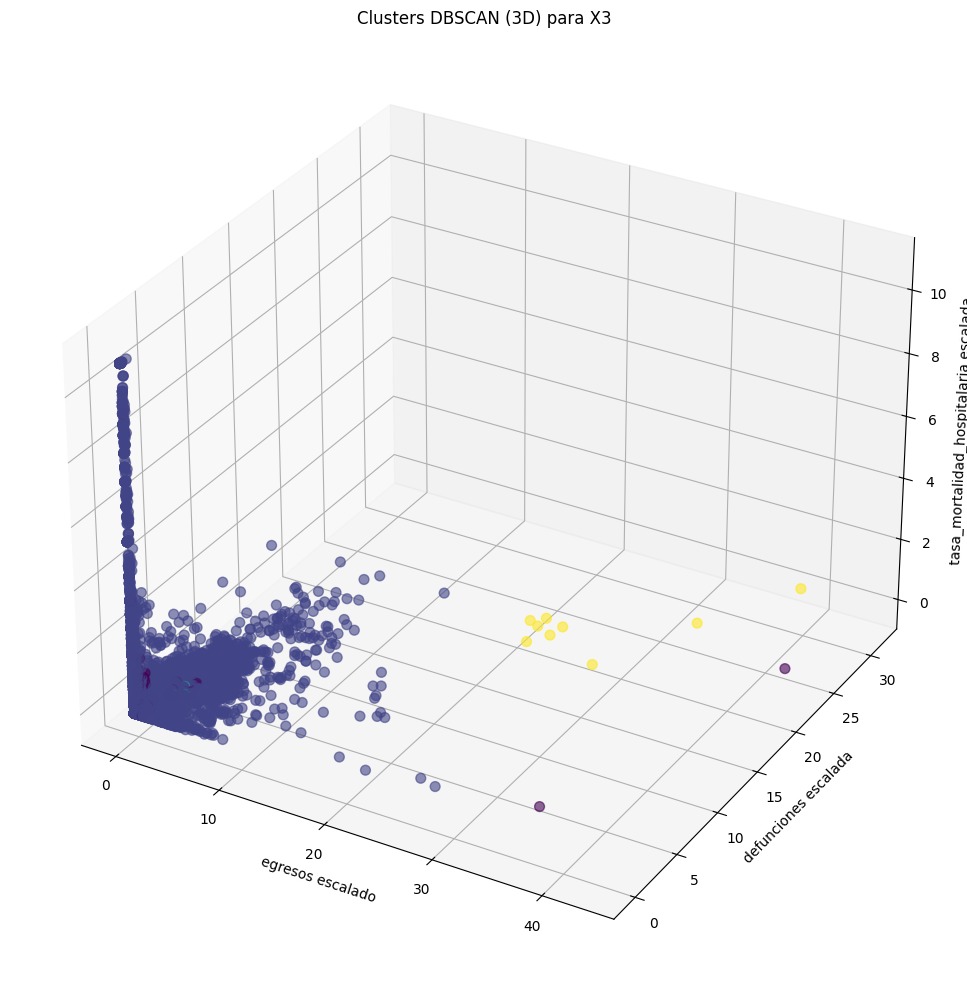

In [55]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')
# Gráfico de puntos
ax.scatter(X3[:, 0], X3[:, 1], X3[:, 2],
           c=labels_x2, cmap='viridis', marker='o', s=50, alpha=0.6)
# Etiquetas
ax.set_title('Clusters DBSCAN (3D) para X3')
ax.set_xlabel(f'{columnas_X3[0]} escalado')
ax.set_ylabel(f'{columnas_X3[1]} escalada')
ax.set_zlabel(f'{columnas_X3[2]} escalada')

plt.tight_layout()
plt.show()

📊 **Conclusión del gráfico Clusters DBSCAN (3D) para X3: egresos vs defunciones vs tasa_mortalidad_hospitalaria**

Este gráfico 3D visualiza la segmentación de los establecimientos hospitalarios en función de sus resultados sanitarios: volumen de pacientes dados de alta (egresos), número absoluto de fallecimientos (defunciones) y la tasa de mortalidad hospitalaria.

🔹 Confirmación de las relaciones y el cluster principal El cluster principal (el grupo más denso) se concentra en la región de bajos valores para las tres variables. Esto confirma que la mayoría de los establecimientos tienen un bajo volumen de egresos, un número bajo de defunciones y, en general, una tasa de mortalidad hospitalaria baja. Este cluster representa a la vasta mayoría de establecimientos con bajo volumen de actividad y buenos resultados sanitarios relativos.

🔹 Ampliación (segmentación) y puntos atípicos Los otros clusters identificados por DBSCAN (los puntos de otros colores), aunque menos numerosos, se distribuyen en áreas del gráfico con valores más altos en egresos y defunciones, representando establecimientos de mayor volumen de actividad. La variable tasa_mortalidad_hospitalaria puede variar dentro de estos clusters de mayor volumen, indicando diferentes niveles de desempeño relativo a pesar del alto número absoluto de defunciones.

Los puntos de ruido (-1) son especialmente relevantes en este gráfico 3D. Estos establecimientos tienen combinaciones atípicas de egresos, defunciones y tasa de mortalidad. Se dispersan lejos de los clusters principales y podrían ser, por ejemplo:

Establecimientos con un volumen muy alto de egresos y defunciones, pero una tasa de mortalidad inusualmente baja. Establecimientos con un volumen bajo de egresos pero una tasa de mortalidad muy alta (lo que indica problemas de calidad o especialización en casos críticos). Establecimientos con perfiles de resultados sanitarios muy diferentes que no encajan en los patrones comunes. En resumen, el gráfico 3D nos ayuda a identificar no solo los grupos mayoritarios de establecimientos según su volumen de resultados sanitarios, sino también a destacar visualmente aquellos casos extremos que se comportan de manera inusual en estas tres dimensiones clave, lo cual es fundamental para identificar áreas de éxito o posibles problemas en la atención médica.

--- 

## 📄 Conclusión General: Comparación entre K-Means y DBSCAN

Ambos algoritmos de clustering, K-Means y DBSCAN, fueron aplicados a los tres conjuntos de variables (X1, X2, X3) **para identificar patrones en el rendimiento de los establecimientos de salud.** Los resultados muestran diferencias claves en cómo cada método aborda la estructura de los datos.

## K-Means (con k=3):

  📈 **Resultados:** Consistentemente produjo 3 clusters para cada conjunto de datos. Los centroides y los gráficos (pairplots, 2D y 3D) mostraron una separación clara entre estos 3 grupos, especialmente evidente en los análisis de promedios por cluster.

  💡**Interpretación:** Los 3 clusters de K-Means parecieron capturar diferentes "escalas" o "niveles" de actividad/resultados (bajo, medio, alto) dentro de cada conjunto de variables. Por ejemplo, en X1 (Atención Ambulatoria), se identificaron grupos de baja, media y alta utilización de servicios. En X2 (Internación), se vieron grupos basados en la capacidad y actividad. En X3 (Resultados Sanitarios), se destacaron grupos de bajo, alto volumen y un grupo con alta tasa de mortalidad relativa.

  ✅ **Ventajas en este contexto:** La pre-especificación de k=3 (basada en el método del codo, aunque la "rodilla" no fue siempre súper pronunciada) forzó una partición equitativa de los datos en un número manejable de grupos, lo que facilitó una interpretación clara de perfiles promedio. Los clusters son más uniformes en tamaño (aunque con diferencias notables, como el Cluster 0 en X1 siendo mucho más grande).

  🚧 **Desventajas en este contexto:** K-Means asume clusters esféricos y de tamaño similar, lo cual no se ajusta perfectamente a la densidad real de los datos, especialmente visible en los pairplots donde los clusters se solapan en algunas dimensiones o muestran formas no esféricas. No identifica "ruido".

## DBSCAN (con eps=2.5, min_samples=4):

  📈 **Resultados:** El número de clusters varió (X1: 2, X2: 5, X3: 3). Identificó un número significativo de puntos como "ruido" (-1), especialmente en X1 (58) y X2 (58).

  💡**Interpretación:** DBSCAN tiende a encontrar un gran cluster principal (representando la mayoría de los establecimientos con valores bajos en las variables) y clusters más pequeños que representan regiones de mayor densidad o patrones específicos. La identificación del "ruido" es valiosa, ya que señala establecimientos que son atípicos y se alejan de los patrones densos principales.

  ✅ **Ventajas en este contexto:** No requiere especificar k, es capaz de encontrar clusters de formas irregulares y, lo más importante, identifica outliers (ruido), que en un contexto de salud pueden ser establecimientos con un rendimiento o características muy diferentes al resto. La visualización 2D y 3D con los resultados de DBSCAN resalta mejor la gran concentración de datos en la región de bajos valores y la dispersión de los outliers.

  🚧 **Desventajas en este contexto:** Los datos tienen densidades muy variadas, por lo tanto, DBSCAN puede tener dificultades para encontrar todos los clusters relevantes. Y la interpretación de muchos clusters pequeños o del "ruido" puede requerir un análisis adicional.

En nuestro contexto de datos ambos métodos se complementan y ofrecen una visión más completa de la estructura de los datos. K-Means da una estructura de 3 perfiles interpretables, mientras que DBSCAN valida la existencia de un gran grupo de baja actividad y señala la presencia de outliers importantes.

